# Srikanth S

## ID : IITP_AIML_2506387

## Capstone Project: D2C Customer Churn Intelligence & Retention API
## Part 1 - Data Audit, EDA & Business Understanding 

In [23]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Relative path for data files
data_path = "./data/"
image_path = "./images/"


## 1.	Load and inspect all raw datasets:

    a.	customers,

    b.	orders,

    c.	support tickets,

    d.	web/app events,

    e.	churn labels,

    f.	intervention/campaign history,
    
    g.	rfm modeling snapshot



In [24]:
def load_and_inspect_data():
        
    dfs = {}
    for name, file_name in datasets.items():
        print(f"\n>>> Inspecting dataset: {name}")
        path = data_path + file_name
        df = pd.read_csv(path)
        dfs[name] = df
        
        # Display basic information
        print(f"Shape: {df.shape}")
        print("\n--- Columns and Data Types (.info()) ---")
        df.info()
        print("\n--- First 2 Records ---")
        print(df.head(2))
        print("-" * 50,"\n\n")
    return dfs


print("==================================================")
print("1. LOADING AND INSPECTING RAW DATASETS")
print("==================================================")

datasets = {
        'Customers': 'customers.csv',
        'Orders': 'orders.csv',
        'Support Tickets': 'support_tickets.csv',
        'Web/App Events': 'web_events_snapshot.csv',
        'Churn Labels': 'churn_labels.csv',
        'Intervention History': 'intervention_history.csv',
        'RFM Modeling Snapshot': 'rfm_modeling_snapshot.csv'
    }

dfs = load_and_inspect_data()

# Convert columns having date info to datetime format

dfs['Customers'].signup_date = pd.to_datetime(dfs['Customers'].signup_date)
dfs['Orders'].order_date = pd.to_datetime(dfs['Orders'].order_date)
dfs['Churn Labels'].snapshot_date = pd.to_datetime(dfs['Churn Labels'].snapshot_date)

1. LOADING AND INSPECTING RAW DATASETS

>>> Inspecting dataset: Customers
Shape: (2400, 9)

--- Columns and Data Types (.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   signup_date          2400 non-null   str  
 2   city_tier            2400 non-null   str  
 3   age_group            2400 non-null   str  
 4   acquisition_channel  2400 non-null   str  
 5   loyalty_tier         1014 non-null   str  
 6   preferred_category   2400 non-null   str  
 7   skin_type            1999 non-null   str  
 8   marketing_consent    2400 non-null   str  
dtypes: str(9)
memory usage: 168.9 KB

--- First 2 Records ---
  customer_id signup_date city_tier age_group acquisition_channel  \
0   CUST00001  2024-04-24    Tier 1     18-24           Instagram   
1   CUST00002  2025-06-01    Tier 2     25-

## 2.	Create a data-quality report covering:
a.	missing values,

b.	duplicate or duplicate-like records,

c.	invalid or unusual values,

d.	outliers,

e.	join/key issues,

f.	date consistency issues,

g.	columns that may cause leakage if used incorrectly.


In [25]:
    print("\n==================================================")
    print("2. DATA-QUALITY REPORT")
    print("==================================================")
    
    # a. Missing Values
    print("\n--- a. Missing Values per Dataset ---")
    for name, df in dfs.items():
        missing = df.isnull().sum()
        missing_pct = 100 * df.isnull().sum() / len(df)
        missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
        missing_df = missing_df[missing_df['Missing Count'] > 0]
        if not missing_df.empty:
            print(f"\nMissing values in {name}:")
            print(missing_df, "\n")
        else:
            print(f"No missing values in {name}\n")



2. DATA-QUALITY REPORT

--- a. Missing Values per Dataset ---

Missing values in Customers:
              Missing Count  Percentage (%)
loyalty_tier           1386       57.750000
skin_type               401       16.708333 


Missing values in Orders:
        Missing Count  Percentage (%)
rating             80        0.799281 

No missing values in Support Tickets

No missing values in Web/App Events

No missing values in Churn Labels

No missing values in Intervention History


Missing values in RFM Modeling Snapshot:
              Missing Count  Percentage (%)
loyalty_tier           1386           57.75 



In [26]:
# b. Duplicate or Duplicate-Like Records

print("\n--- b. Duplicate Records / Unique Keys Check ---")
for name, df in dfs.items():
    print(f"Duplicate rows in {name} table : {df.duplicated().sum()}")
print ("\n")

# Check based on key fields
cust = dfs['Customers']
orders = dfs['Orders']
tickets = dfs['Support Tickets']
web = dfs['Web/App Events']
churn = dfs['Churn Labels']
interv = dfs['Intervention History']
rfm = dfs['RFM Modeling Snapshot']

print(f"Duplicate customer rows: {cust.duplicated().sum()}")
print(f"Duplicate order IDs: {orders['order_id'].duplicated().sum()}")
print(f"Duplicate ticket IDs: {tickets['ticket_id'].duplicated().sum()}")
print(f"Duplicate customer entries in Web Events: {web['customer_id'].duplicated().sum()}")
print(f"Duplicate customer entries in Churn Labels: {churn['customer_id'].duplicated().sum()}")
print(f"Duplicate customer entries in Intervention History: {interv['customer_id'].duplicated().sum()}")

# Duplicate-like rows

dup_orders = orders[orders['order_id'].astype(str).str.endswith('DUP')]
print(f"Total orders found with suffix 'DUP': {len(dup_orders)}")

# Print the matching records
print("\nMatching Duplicate-like Records:")
print(dup_orders)



--- b. Duplicate Records / Unique Keys Check ---
Duplicate rows in Customers table : 0
Duplicate rows in Orders table : 0
Duplicate rows in Support Tickets table : 0
Duplicate rows in Web/App Events table : 0
Duplicate rows in Churn Labels table : 0
Duplicate rows in Intervention History table : 0
Duplicate rows in RFM Modeling Snapshot table : 0


Duplicate customer rows: 0
Duplicate order IDs: 0
Duplicate ticket IDs: 0
Duplicate customer entries in Web Events: 0
Duplicate customer entries in Churn Labels: 0
Duplicate customer entries in Intervention History: 0
Total orders found with suffix 'DUP': 12

Matching Duplicate-like Records:
           order_id customer_id order_date   category  quantity  gross_amount  \
601   ORD008249_DUP   CUST00153 2025-11-04  Hair Care         1        321.31   
2621  ORD002124_DUP   CUST00628 2025-03-18  Skin Care         1        410.04   
3534  ORD002862_DUP   CUST00837 2025-07-12  Hair Care         3        952.02   
3602  ORD002916_DUP   CUST00848

In [27]:
# c & d : Invalid or Unusual Values & Outliers
print("\n--- c & d. Unusual Values & Outliers ---")
print("Orders table quantitative ranges:")
print(orders[['quantity', 'gross_amount', 'discount_pct', 'delivery_days', 'rating']].describe())

print("\nSupport Tickets quantitative ranges:")
print(tickets[['resolution_hours', 'sentiment_score', 'reopened']].describe())


--- c & d. Unusual Values & Outliers ---
Orders table quantitative ranges:
           quantity  gross_amount  discount_pct  delivery_days       rating
count  10009.000000  10009.000000  10009.000000   10009.000000  9929.000000
mean       1.507943    743.898504      0.274121       4.454591     3.885487
std        0.764261    600.564068      0.125525       1.769649     1.159465
min        1.000000    149.000000      0.000000       1.000000     1.000000
25%        1.000000    432.850000      0.190000       3.000000     3.000000
50%        1.000000    597.060000      0.270000       4.000000     4.000000
75%        2.000000    907.430000      0.360000       6.000000     5.000000
max        4.000000  24789.380000      0.700000      11.000000     5.000000

Support Tickets quantitative ranges:
       resolution_hours  sentiment_score     reopened
count       1921.000000      1921.000000  1921.000000
mean          24.789276        -0.440770     0.176991
std           14.270666         0.473244

In [28]:
# e. Join / Key Issues
print("\n--- e. Join/Key Integrity Issues ---")
cust_ids = set(cust['customer_id'])
print(f"Orders with unlinked customer_id: {len(orders[~orders['customer_id'].isin(cust_ids)])}")
print(f"Tickets with unlinked customer_id: {len(tickets[~tickets['customer_id'].isin(cust_ids)])}")
print(f"Web events with unlinked customer_id: {len(web[~web['customer_id'].isin(cust_ids)])}")
print(f"Churn labels with unlinked customer_id: {len(churn[~churn['customer_id'].isin(cust_ids)])}")
print(f"Interventions with unlinked customer_id: {len(interv[~interv['customer_id'].isin(cust_ids)])}")

# f. Date Consistency Issues
print("\n--- f. Date Consistency Issues ---")
cust_dates = cust[['customer_id', 'signup_date']].copy()
cust_dates['signup_date'] = pd.to_datetime(cust_dates['signup_date'])

orders_dt = orders[['customer_id', 'order_date']].copy()
orders_dt['order_date'] = pd.to_datetime(orders_dt['order_date'])
orders_m = orders_dt.merge(cust_dates, on='customer_id', how='left')
orders_before_signup = orders_m[orders_m['order_date'] < orders_m['signup_date']]
print(f"Orders placed BEFORE customer signup date: {len(orders_before_signup)}")



--- e. Join/Key Integrity Issues ---
Orders with unlinked customer_id: 0
Tickets with unlinked customer_id: 0
Web events with unlinked customer_id: 0
Churn labels with unlinked customer_id: 0
Interventions with unlinked customer_id: 0

--- f. Date Consistency Issues ---
Orders placed BEFORE customer signup date: 0


In [29]:
# g. Data Leakage Assessment
print("\n--- g. Columns and Records causing Data Leakage ---")
snapshot_date = pd.to_datetime('2025-09-30')

post_snapshot_orders = len(orders_dt[orders_dt['order_date'] > snapshot_date])
print(f"Total orders dated AFTER snapshot date ({snapshot_date.strftime('%Y-%m-%d')}): {post_snapshot_orders}")
print("CRITICAL: These future orders represent target window activity and will cause absolute data leakage if included in features!")



--- g. Columns and Records causing Data Leakage ---
Total orders dated AFTER snapshot date (2025-09-30): 1872
CRITICAL: These future orders represent target window activity and will cause absolute data leakage if included in features!


## 3.	Perform exploratory analysis on:

a.	customer demographics/profile fields,

b.	order behaviour,

c.	monetary behaviour,

d.	support-ticket issues,

e.	return/refund behaviour,

f.	web/app activity,

g.	campaign or intervention history,

h.	churn distribution.

In [30]:
print("\n==================================================")
print("3. EXPLORATORY DATA ANALYSIS (EDA)")
print("==================================================")

# a. Customer Demographics
print("\n--- a. Customer Demographics / Profile Fields ---")
demo_cols = ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent']
for col in demo_cols:
  print(f"\nDistribution for '{col}':")
  print(cust[col].value_counts(dropna=False, normalize=True) * 100)


3. EXPLORATORY DATA ANALYSIS (EDA)

--- a. Customer Demographics / Profile Fields ---

Distribution for 'city_tier':
city_tier
Tier 1    41.875
Tier 2    36.250
Tier 3    21.875
Name: proportion, dtype: float64

Distribution for 'age_group':
age_group
25-34    43.541667
18-24    23.333333
35-44    22.250000
45+      10.875000
Name: proportion, dtype: float64

Distribution for 'acquisition_channel':
acquisition_channel
Instagram        21.541667
Google Search    19.416667
Marketplace      19.000000
Referral         16.500000
Organic          13.916667
Influencer        9.625000
Name: proportion, dtype: float64

Distribution for 'loyalty_tier':
loyalty_tier
NaN         57.750000
Silver      24.583333
Gold        13.291667
Platinum     4.375000
Name: proportion, dtype: float64

Distribution for 'preferred_category':
preferred_category
Skin Care    30.458333
Hair Care    21.125000
Baby Care    14.458333
Makeup       13.583333
Wellness     10.458333
Fragrance     9.916667
Name: proportion,

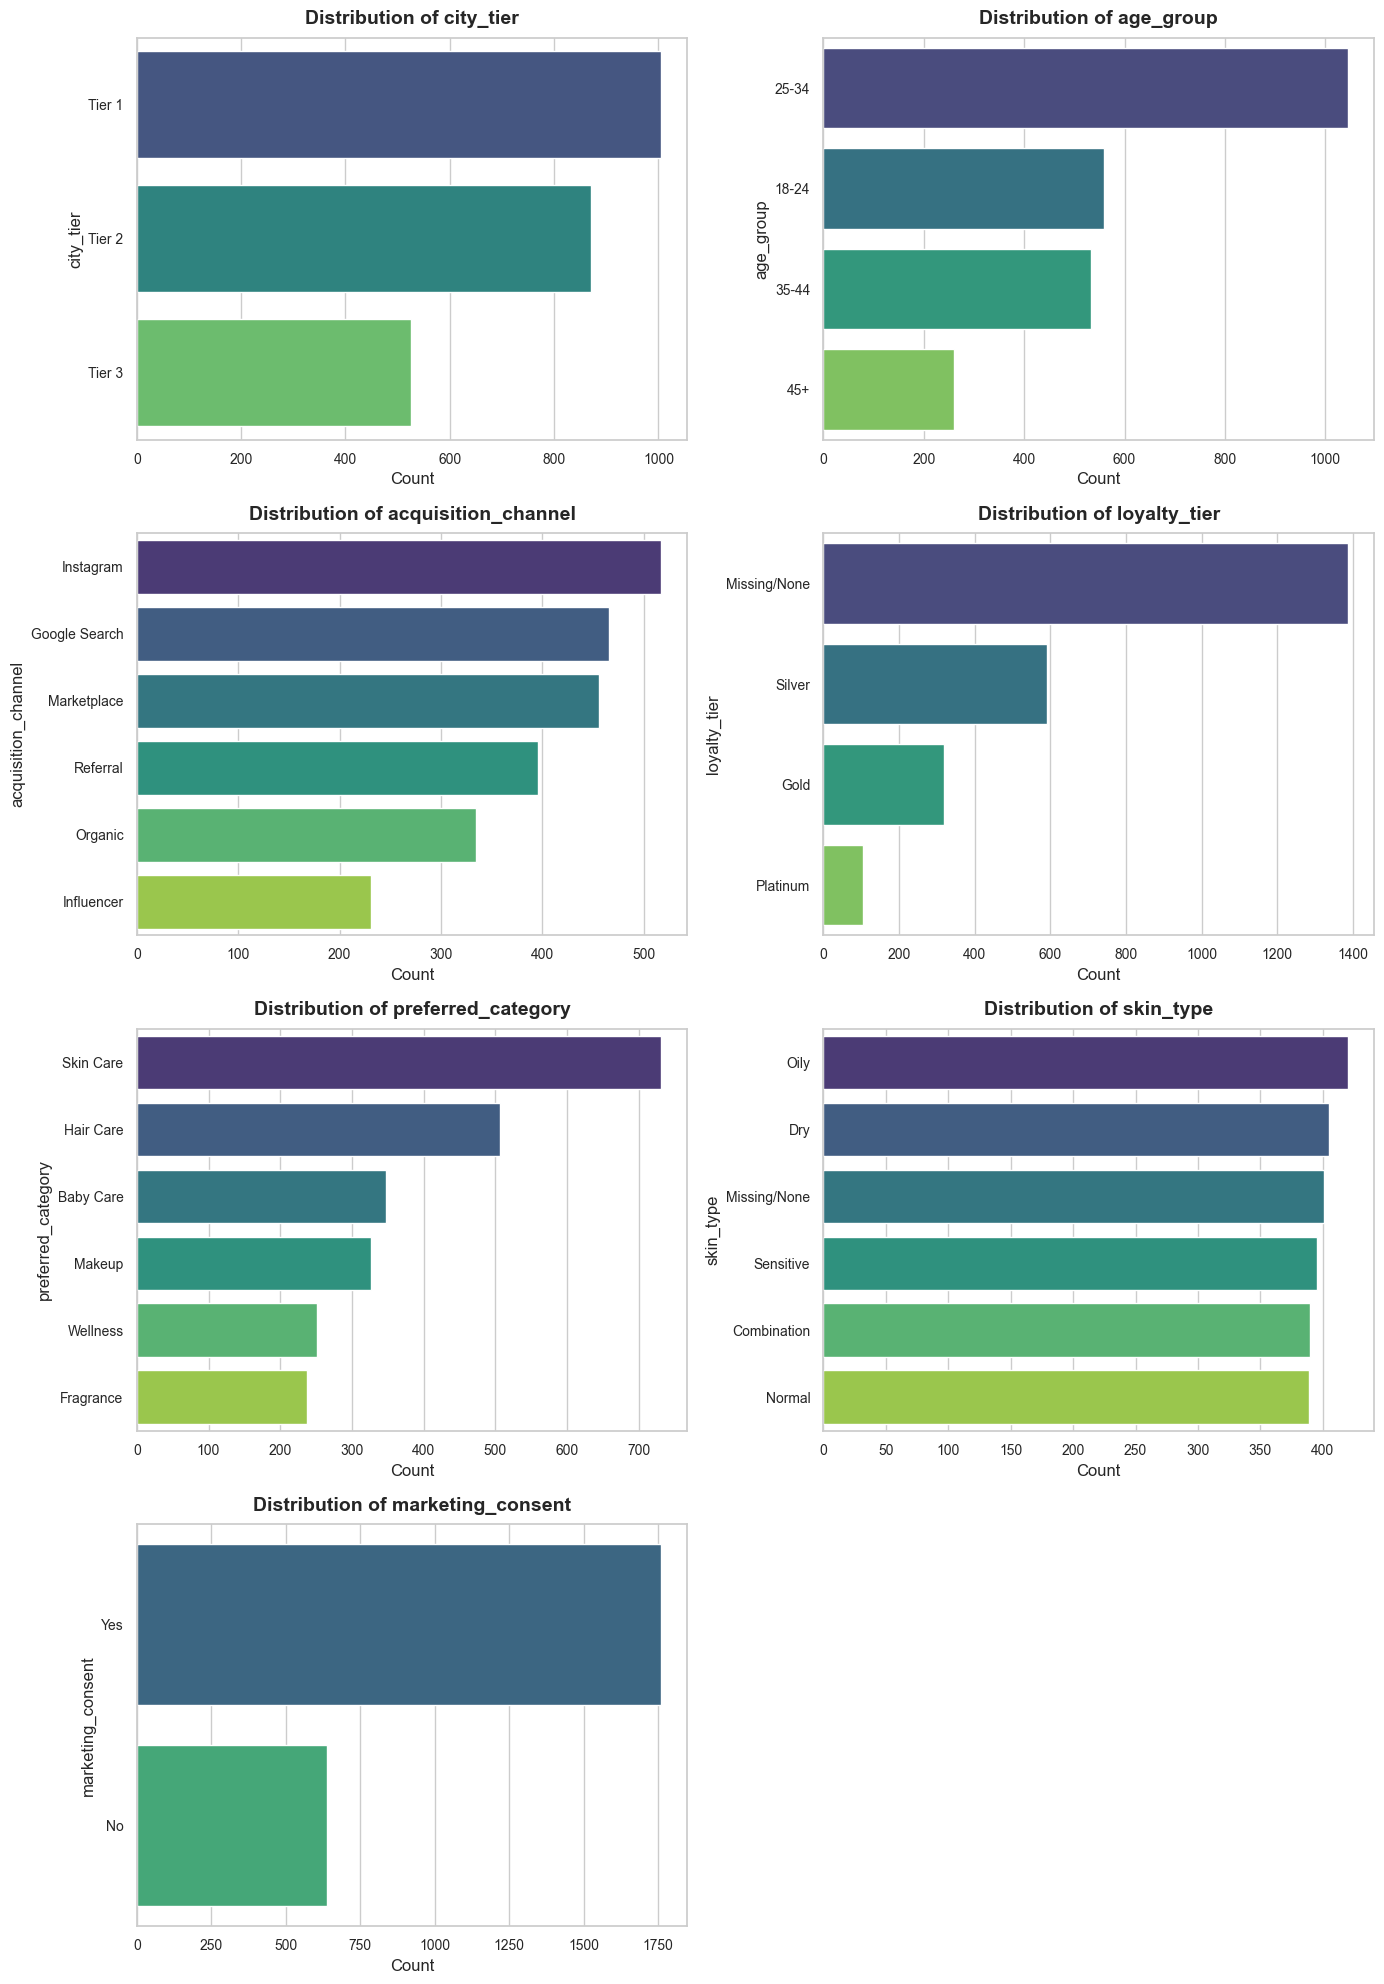

In [31]:
# 
# List of Categorical/category fields in customer file
cat_cols = [
    'city_tier', 
    'age_group', 
    'acquisition_channel', 
    'loyalty_tier', 
    'preferred_category', 
    'skin_type', 
    'marketing_consent'
]

# Initialize a 4x2 grid of subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))

# Flatten the 2D grid matrix to a 1D array for straightforward iteration
axes = axes.flatten()

# 5. Populate the grid with sorted bar charts
for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # Extract value frequencies in a sorted descending order
    data_counts = cust[col].value_counts(dropna=False).reset_index()
    data_counts.columns = [col, 'count']
    
    # Re-label explicit NaN values so they display properly in the plot
    data_counts[col] = data_counts[col].fillna('Missing/None')
    
    # Generate the horizontal bar plot using Seaborn
    sns.barplot(
        x='count', 
        y=col, 
        data=data_counts, 
        ax=ax, 
        palette='viridis', 
        hue=col
    )
    
    # Refine labels, titles, and ticks for maximum legibility without truncation
    ax.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)

# Hide the 8th subplot slot since only 7 categorical features
if len(cat_cols) < len(axes):
    axes[-1].set_visible(False)

# 7. Automatically adjust spacing parameters to fix overlapping issues
plt.tight_layout()

image_name = image_path + 'T3P1_customer_categorical_distributions.png'
plt.savefig(image_name, dpi=300)

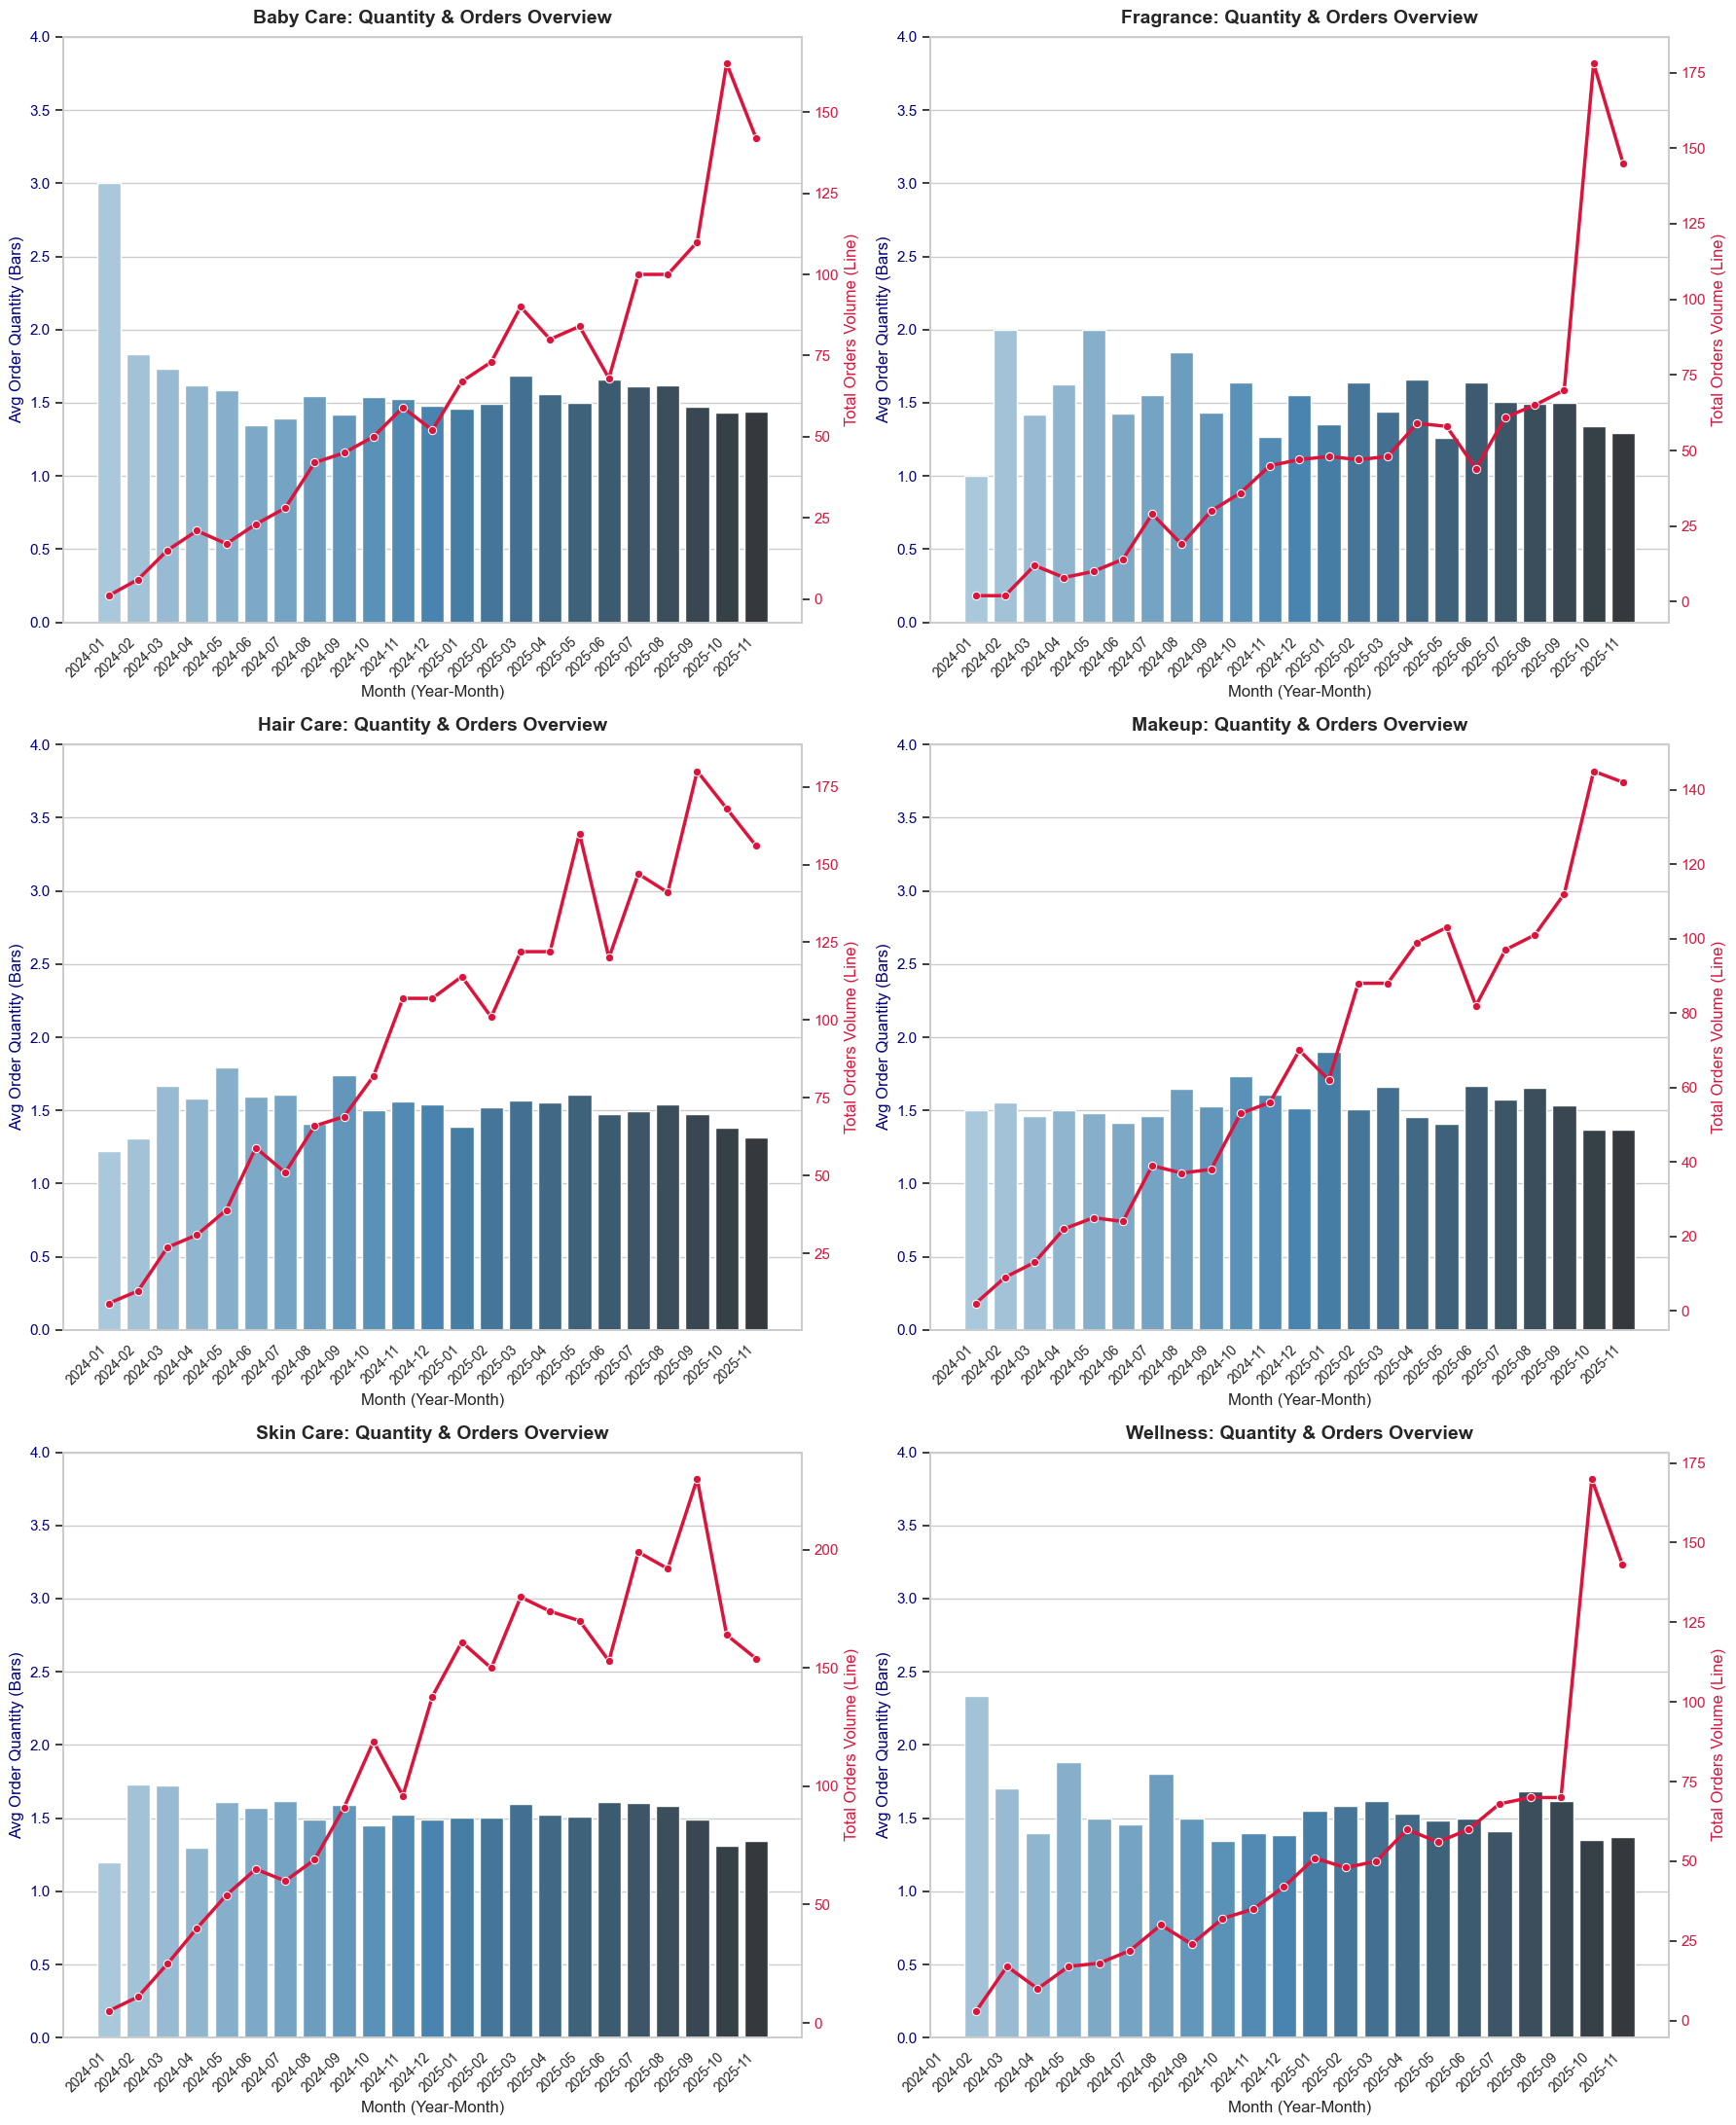

In [32]:
# b. Order EDA

orders['order_date'] = pd.to_datetime(orders['order_date'])

# 2. Extract Year-Month strings to sequence time chronologically
orders['year_month'] = orders['order_date'].dt.to_period('M').astype(str)

# 3. Aggregate data: Mean quantity per order and volume count of total orders
agg_df = orders.groupby(['category', 'year_month']).agg(
    avg_quantity=('quantity', 'mean'),
    total_orders=('order_id', 'count')
).reset_index()

# Sort by Category and Month sequence
agg_df = agg_df.sort_values(['category', 'year_month'])
categories = agg_df['category'].unique()
all_months = sorted(agg_df['year_month'].unique())

# 4. Initialize Seaborn theme and canvas constraints
sns.set_theme(style="whitegrid")

# Create a 3x2 multi-panel layout grid for 6 product categories
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 22))
axes = axes.flatten()

# 5. Populate each panel with the Dual Y-Axis combination chart
for i, cat in enumerate(categories):
    ax1 = axes[i]
    cat_data = agg_df[agg_df['category'] == cat]
    
    # Ensure all months are fully mapped chronologically (fill blanks if any exist)
    cat_data = cat_data.set_index('year_month').reindex(all_months).reset_index()
    
    # --- Primary Left Y-Axis: Bar Chart for Average Order Quantity ---
    sns.barplot(
        x='year_month', 
        y='avg_quantity', 
        data=cat_data, 
        ax=ax1, 
        palette='Blues_d', 
        hue='year_month'
    )
    warnings.filterwarnings('ignore', category=UserWarning)
    # Clear auto-generated seaborn legends to keep plots clean
    if ax1.get_legend() is not None:
        ax1.get_legend().remove()
        
    ax1.set_title(f'{cat}: Quantity & Orders Overview', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xlabel('Month (Year-Month)', fontsize=12)
    ax1.set_ylabel('Avg Order Quantity (Bars)', fontsize=12, color='navy')
    ax1.set_xticklabels(all_months, rotation=45, ha='right', fontsize=10)
    ax1.set_ylim(0, 4)
    ax1.tick_params(axis='y', labelcolor='navy')
    
    # --- Secondary Right Y-Axis: Line Chart for Total Orders Volume ---
    ax2 = ax1.twinx()
    sns.lineplot(
        x=ax1.get_xticks(), 
        y=cat_data['total_orders'], 
        ax=ax2, 
        color='crimson', 
        linewidth=2.5, 
        marker='o', 
        markersize=6
    )
    ax2.set_ylabel('Total Orders Volume (Line)', fontsize=12, color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax2.grid(False)  # Disable dual grid lines to avoid visual confusion

# 6. Apply tight layout margins to safeguard text labels from clipping
warnings.resetwarnings()
plt.tight_layout()

# 7. Export high-fidelity chart out to workspace
image_name = image_path + 'T3P1_category_quantity_and_orders_combo.png'
plt.savefig(image_name, dpi=300)

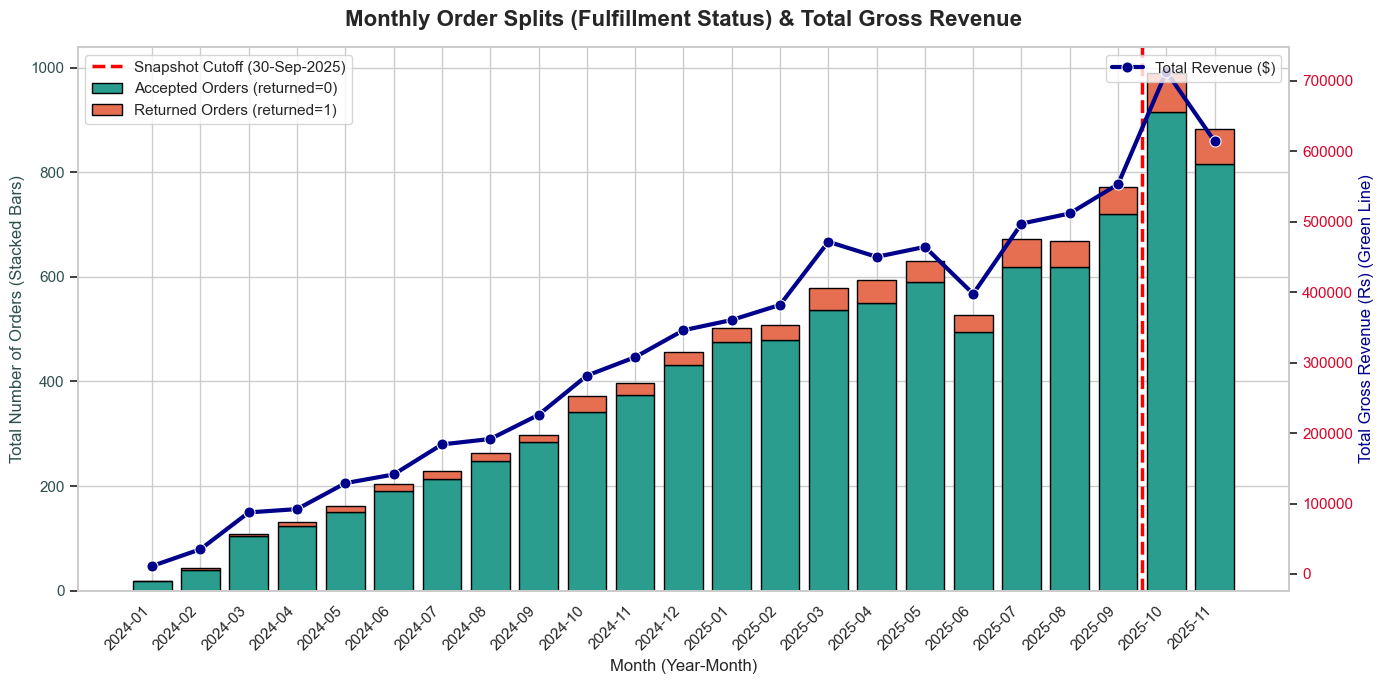

In [33]:
# 2. Extract discrete Year-Month strings for chronological aggregation
orders['year_month'] = orders['order_date'].dt.to_period('M').astype(str)

# 3. Group by month and returned status to extract order fulfillment counts
order_counts = orders.groupby(['year_month', 'returned']).size().unstack(fill_value=0)
order_counts.columns = ['Accepted', 'Returned']

# 4. Group by month to calculate total revenue
monthly_revenue = orders.groupby('year_month')['gross_amount'].sum()

# 5. Consolidate metrics into an ordered dataframe
monthly_stats = pd.DataFrame({
    'Accepted': order_counts['Accepted'],
    'Returned': order_counts['Returned'],
    'Total_Revenue': monthly_revenue
}).reset_index().sort_values('year_month')

# Find the specific coordinate position for September 2025
idx_sep_2025 = monthly_stats[monthly_stats['year_month'] == '2025-09'].index[0]

# 6. Configure plot theme settings via Seaborn
sns.set_theme(style="whitegrid")

# Initialize primary figure plot layout (avoiding direct .figure calls)
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Primary Left Y-Axis: Stacked Bar Chart for Order Volumes ---
ax1.bar(
    monthly_stats['year_month'], 
    monthly_stats['Accepted'], 
    label='Accepted Orders (returned=0)', 
    color='#2a9d8f', 
    edgecolor='black'
)
ax1.bar(
    monthly_stats['year_month'], 
    monthly_stats['Returned'], 
    bottom=monthly_stats['Accepted'], 
    label='Returned Orders (returned=1)', 
    color='#e76f51', 
    edgecolor='black'
)

# Refine labels and ticking for left axis
ax1.set_title('Monthly Order Splits (Fulfillment Status) & Total Gross Revenue', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Month (Year-Month)', fontsize=12)
ax1.set_ylabel('Total Number of Orders (Stacked Bars)', fontsize=12, color='darkslategrey')
ax1.set_xticks(range(len(monthly_stats)))
ax1.set_xticklabels(monthly_stats['year_month'], rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='darkslategrey')

# --- Secondary Right Y-Axis: Line Chart for Total Cumulative Revenue ---
ax2 = ax1.twinx()
sns.lineplot(
    x=ax1.get_xticks(),
    y=monthly_stats['Total_Revenue'],
    ax=ax2,
    color='darkblue',
    linewidth=3,
    marker='o',
    markersize=8,
    label='Total Revenue ($)'
)
# Refine labels and ticking for right axis
ax2.set_ylabel('Total Gross Revenue (Rs) (Green Line)', fontsize=12, color='darkblue')
ax2.tick_params(axis='y', labelcolor='#d90429')
ax2.grid(False) # Turn off overlapping grids

# --- 7. Add Vertical Red Cutoff Timeline Line ---
# Shifted by +0.5 to land exactly on the partition boundary separating Sep and Oct 2025
ax1.axvline(
    x=idx_sep_2025 + 0.5, 
    color='red', 
    linestyle='--', 
    linewidth=2.5, 
    label='Snapshot Cutoff (30-Sep-2025)'
)

# Render crisp multi-axis legends
ax1.legend(loc='upper left', frameon=True)
ax2.legend(loc='upper right', frameon=True)

# 8. Tighten alignment space and save chart to disk
plt.tight_layout()
image_name = image_path + 'T3P1_monthly_orders_split_and_revenue.png'
plt.savefig(image_name, dpi=300)


--- c. Monetary Behaviour ---
Average Order Gross Amount: 743.90
Median Order Gross Amount: 597.06
Average Discount Percent: 27.41%
Average Items Per Order (Quantity): 1.51

Order counts by category:
category
Skin Care    26.975722
Hair Care    21.890299
Makeup       15.056449
Baby Care    14.367070
Wellness     10.950145
Fragrance    10.760316
Name: proportion, dtype: float64

Orders more than upper limit : 536
Orders less than lower limit : 0
Orders less than IQR lower bound : 2502


C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


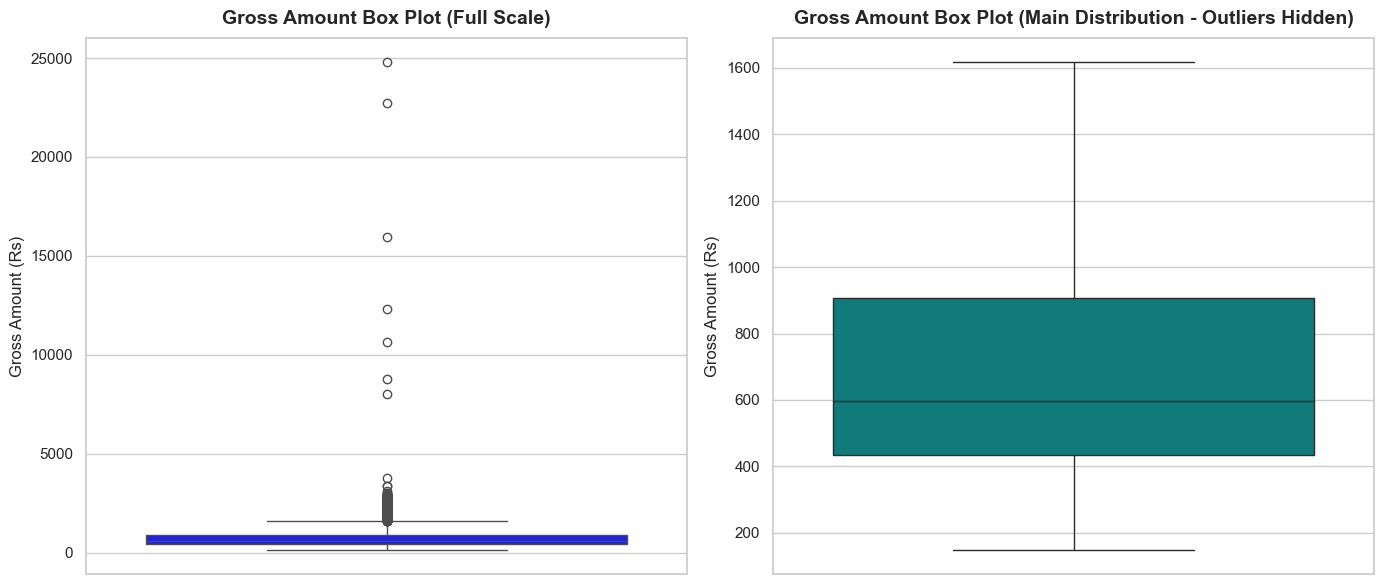

In [34]:
# c Monetary Behaviour

print("\n--- c. Monetary Behaviour ---")
print(f"Average Order Gross Amount: {orders['gross_amount'].mean():.2f}")
print(f"Median Order Gross Amount: {orders['gross_amount'].median():.2f}")
print(f"Average Discount Percent: {orders['discount_pct'].mean() * 100:.2f}%")
print(f"Average Items Per Order (Quantity): {orders['quantity'].mean():.2f}")
print("\nOrder counts by category:")
print(orders['category'].value_counts(normalize=True) * 100)

# IQR

order_iqr = orders['gross_amount'].quantile(0.75) - orders['gross_amount'].quantile(0.25)
upper_bound = orders['gross_amount'].quantile(0.75) + 1.5*order_iqr 
lower_bound = orders['gross_amount'].quantile(0.25) - 1.5*order_iqr 
print (f"\nOrders more than upper limit : {(orders['gross_amount'] > upper_bound).sum()}")
print (f"Orders less than lower limit : {(orders['gross_amount'] < lower_bound).sum()}")
print (f"Orders less than IQR lower bound : {(orders['gross_amount'] < orders['gross_amount'].quantile(0.25)).sum()}")


# Left plot: Full Scale box plot showing all extreme outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(y=orders['gross_amount'], ax=axes[0], color='blue')
axes[0].set_title('Gross Amount Box Plot (Full Scale)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel('Gross Amount (Rs)', fontsize=12)

# Right plot: Focussed view hiding outliers to analyze the core distribution metrics
sns.boxplot(y=orders['gross_amount'], ax=axes[1], color='darkcyan', showfliers=False)
axes[1].set_title('Gross Amount Box Plot (Main Distribution - Outliers Hidden)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_ylabel('Gross Amount (Rs)', fontsize=12)

plt.tight_layout()

Processed tables successfully written to workspace.


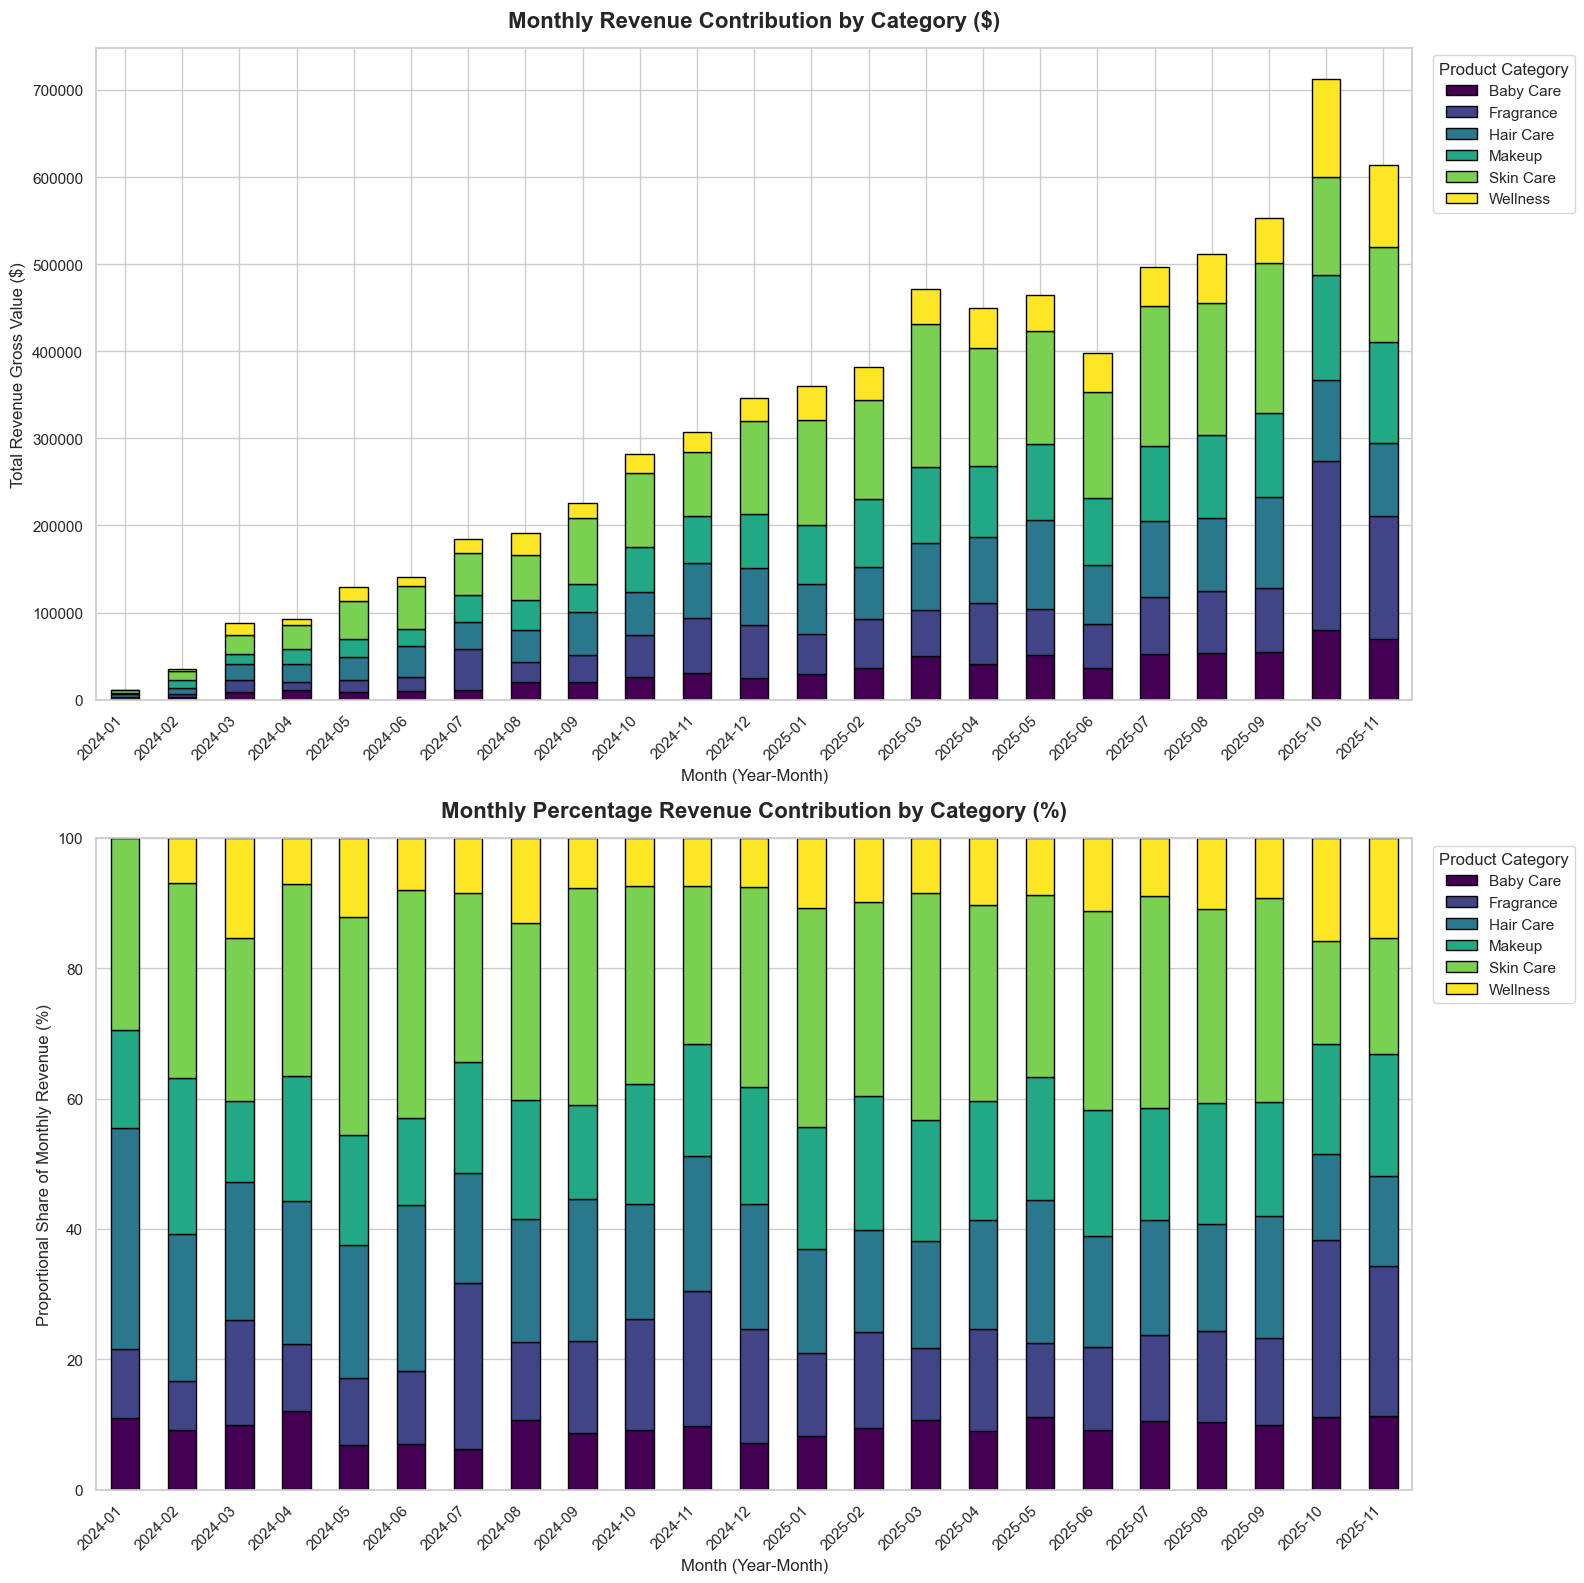

In [35]:
# c. Monetary EDA

orders['order_date'] = pd.to_datetime(orders['order_date'])

# 2. Extract Year-Month periods as discrete strings for chronological grouping
orders['year_month'] = orders['order_date'].dt.to_period('M').astype(str)

# 3. Calculate Absolute Revenue (sum of gross_amount) per category per month
revenue_df = (
    orders.groupby(['year_month', 'category'])['gross_amount']
    .sum()
    .unstack(fill_value=0)
)

# 4. Calculate Relative Percentage Contribution per category per month
revenue_pct_df = revenue_df.div(revenue_df.sum(axis=1), axis=0) * 100

# Write the processed analytical data frames out to CSV files
revenue_df.to_csv('monthly_revenue_by_category.csv')
revenue_pct_df.to_csv('monthly_revenue_percentage_by_category.csv')
print("Processed tables successfully written to workspace.")

# 5. Set up plot styling parameters
sns.set_theme(style="whitegrid")

# Initialize a 2x1 grid of stacked subplots (avoiding direct .figure calls)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 16))

# Chart 1: Absolute Monthly Revenue Contribution Stacked Bar Chart
revenue_df.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis', edgecolor='black')
axes[0].set_title('Monthly Revenue Contribution by Category ($)', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Month (Year-Month)', fontsize=12)
axes[0].set_ylabel('Total Revenue Gross Value ($)', fontsize=12)
axes[0].set_xticklabels(revenue_df.index, rotation=45, ha='right')
axes[0].legend(title='Product Category', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)

# Chart 2: Relative Percentage Monthly Revenue Contribution Stacked Bar Chart
revenue_pct_df.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis', edgecolor='black')
axes[1].set_title('Monthly Percentage Revenue Contribution by Category (%)', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Month (Year-Month)', fontsize=12)
axes[1].set_ylabel('Proportional Share of Monthly Revenue (%)', fontsize=12)
axes[1].set_xticklabels(revenue_pct_df.index, rotation=45, ha='right')
axes[1].legend(title='Product Category', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.tight_layout()

C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\homeadm

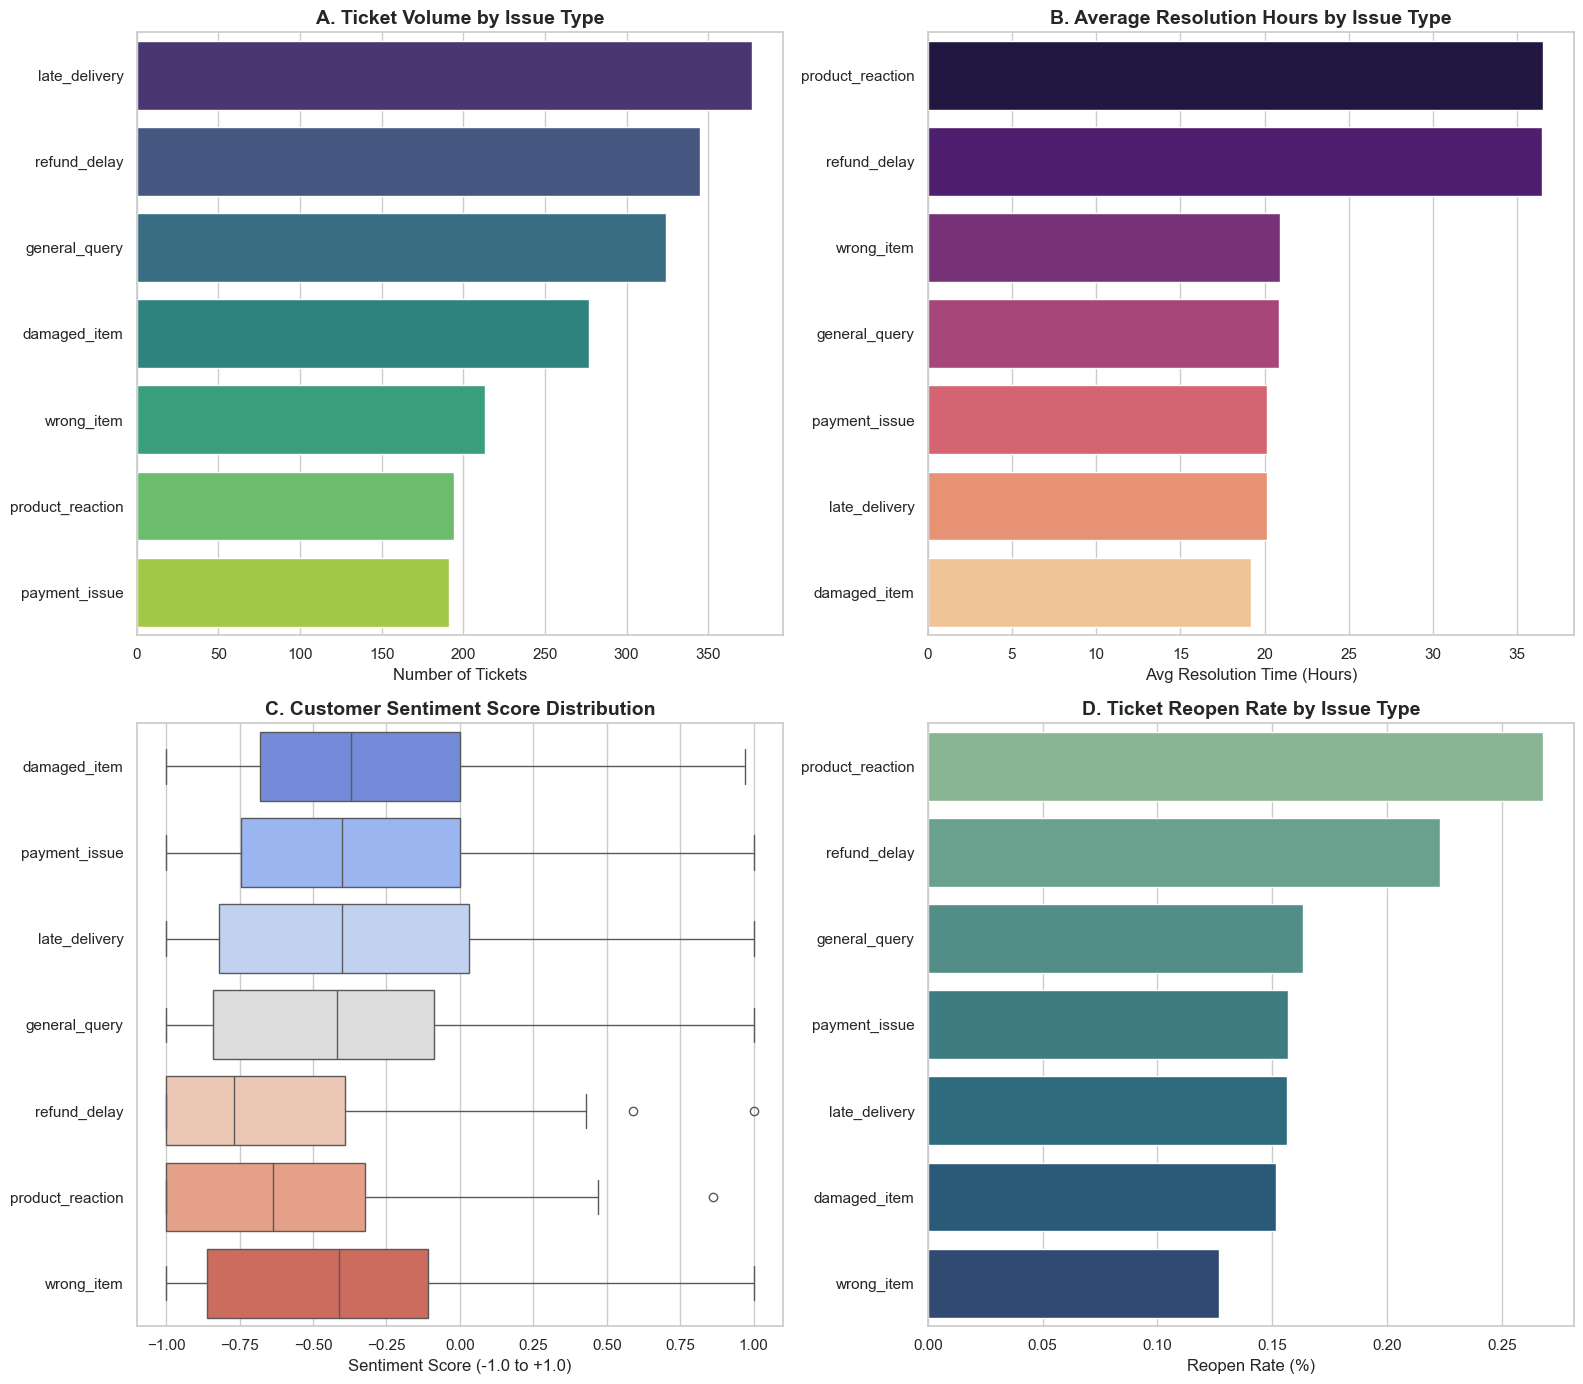

In [36]:
# d. Support tickets

# 1. Convert dates
tickets['ticket_date'] = pd.to_datetime(tickets['ticket_date'])

# 2. Extract operational metrics summarized by issue type
issue_summary = tickets.groupby('issue_type').agg(
    ticket_count=('ticket_id', 'count'),
    avg_resolution_hours=('resolution_hours', 'mean'),
    avg_sentiment=('sentiment_score', 'mean'),
    reopen_rate=('reopened', 'mean')
).reset_index().sort_values(by='avg_resolution_hours', ascending=False)

# 3. Setup visualization grid using seaborn
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))

# Panel A: Ticket Volume by Issue Type
issue_counts = tickets['issue_type'].value_counts().reset_index()
sns.barplot(x='count', y='issue_type', data=issue_counts, ax=axes[0,0], palette='viridis', hue='issue_type')
axes[0,0].set_title('A. Ticket Volume by Issue Type', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Number of Tickets')
axes[0,0].set_ylabel('')
if axes[0,0].get_legend() is not None: axes[0,0].get_legend().remove()

# Panel B: Average Resolution Hours by Issue Type
sns.barplot(x='avg_resolution_hours', y='issue_type', data=issue_summary, ax=axes[0,1], palette='magma', hue='issue_type')
axes[0,1].set_title('B. Average Resolution Hours by Issue Type', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Avg Resolution Time (Hours)')
axes[0,1].set_ylabel('')
if axes[0,1].get_legend() is not None: axes[0,1].get_legend().remove()

# Panel C: Sentiment Score Box Plot by Issue Type
sns.boxplot(x='sentiment_score', y='issue_type', data=tickets, ax=axes[1,0], palette='coolwarm', hue='issue_type')
axes[1,0].set_title('C. Customer Sentiment Score Distribution', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Sentiment Score (-1.0 to +1.0)')
axes[1,0].set_ylabel('')
if axes[1,0].get_legend() is not None: axes[1,0].get_legend().remove()

# Panel D: Reopen Rate by Issue Type
reopen_summary = issue_summary.sort_values(by='reopen_rate', ascending=False)
sns.barplot(x='reopen_rate', y='issue_type', data=reopen_summary, ax=axes[1,1], palette='crest', hue='issue_type')
axes[1,1].set_title('D. Ticket Reopen Rate by Issue Type', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Reopen Rate (%)')
axes[1,1].set_ylabel('')
if axes[1,1].get_legend() is not None: axes[1,1].get_legend().remove()

plt.tight_layout()
image_name = image_path + 'T3P1_support_tickets_eda_dashboard.png'
plt.savefig(image_name, dpi=300)


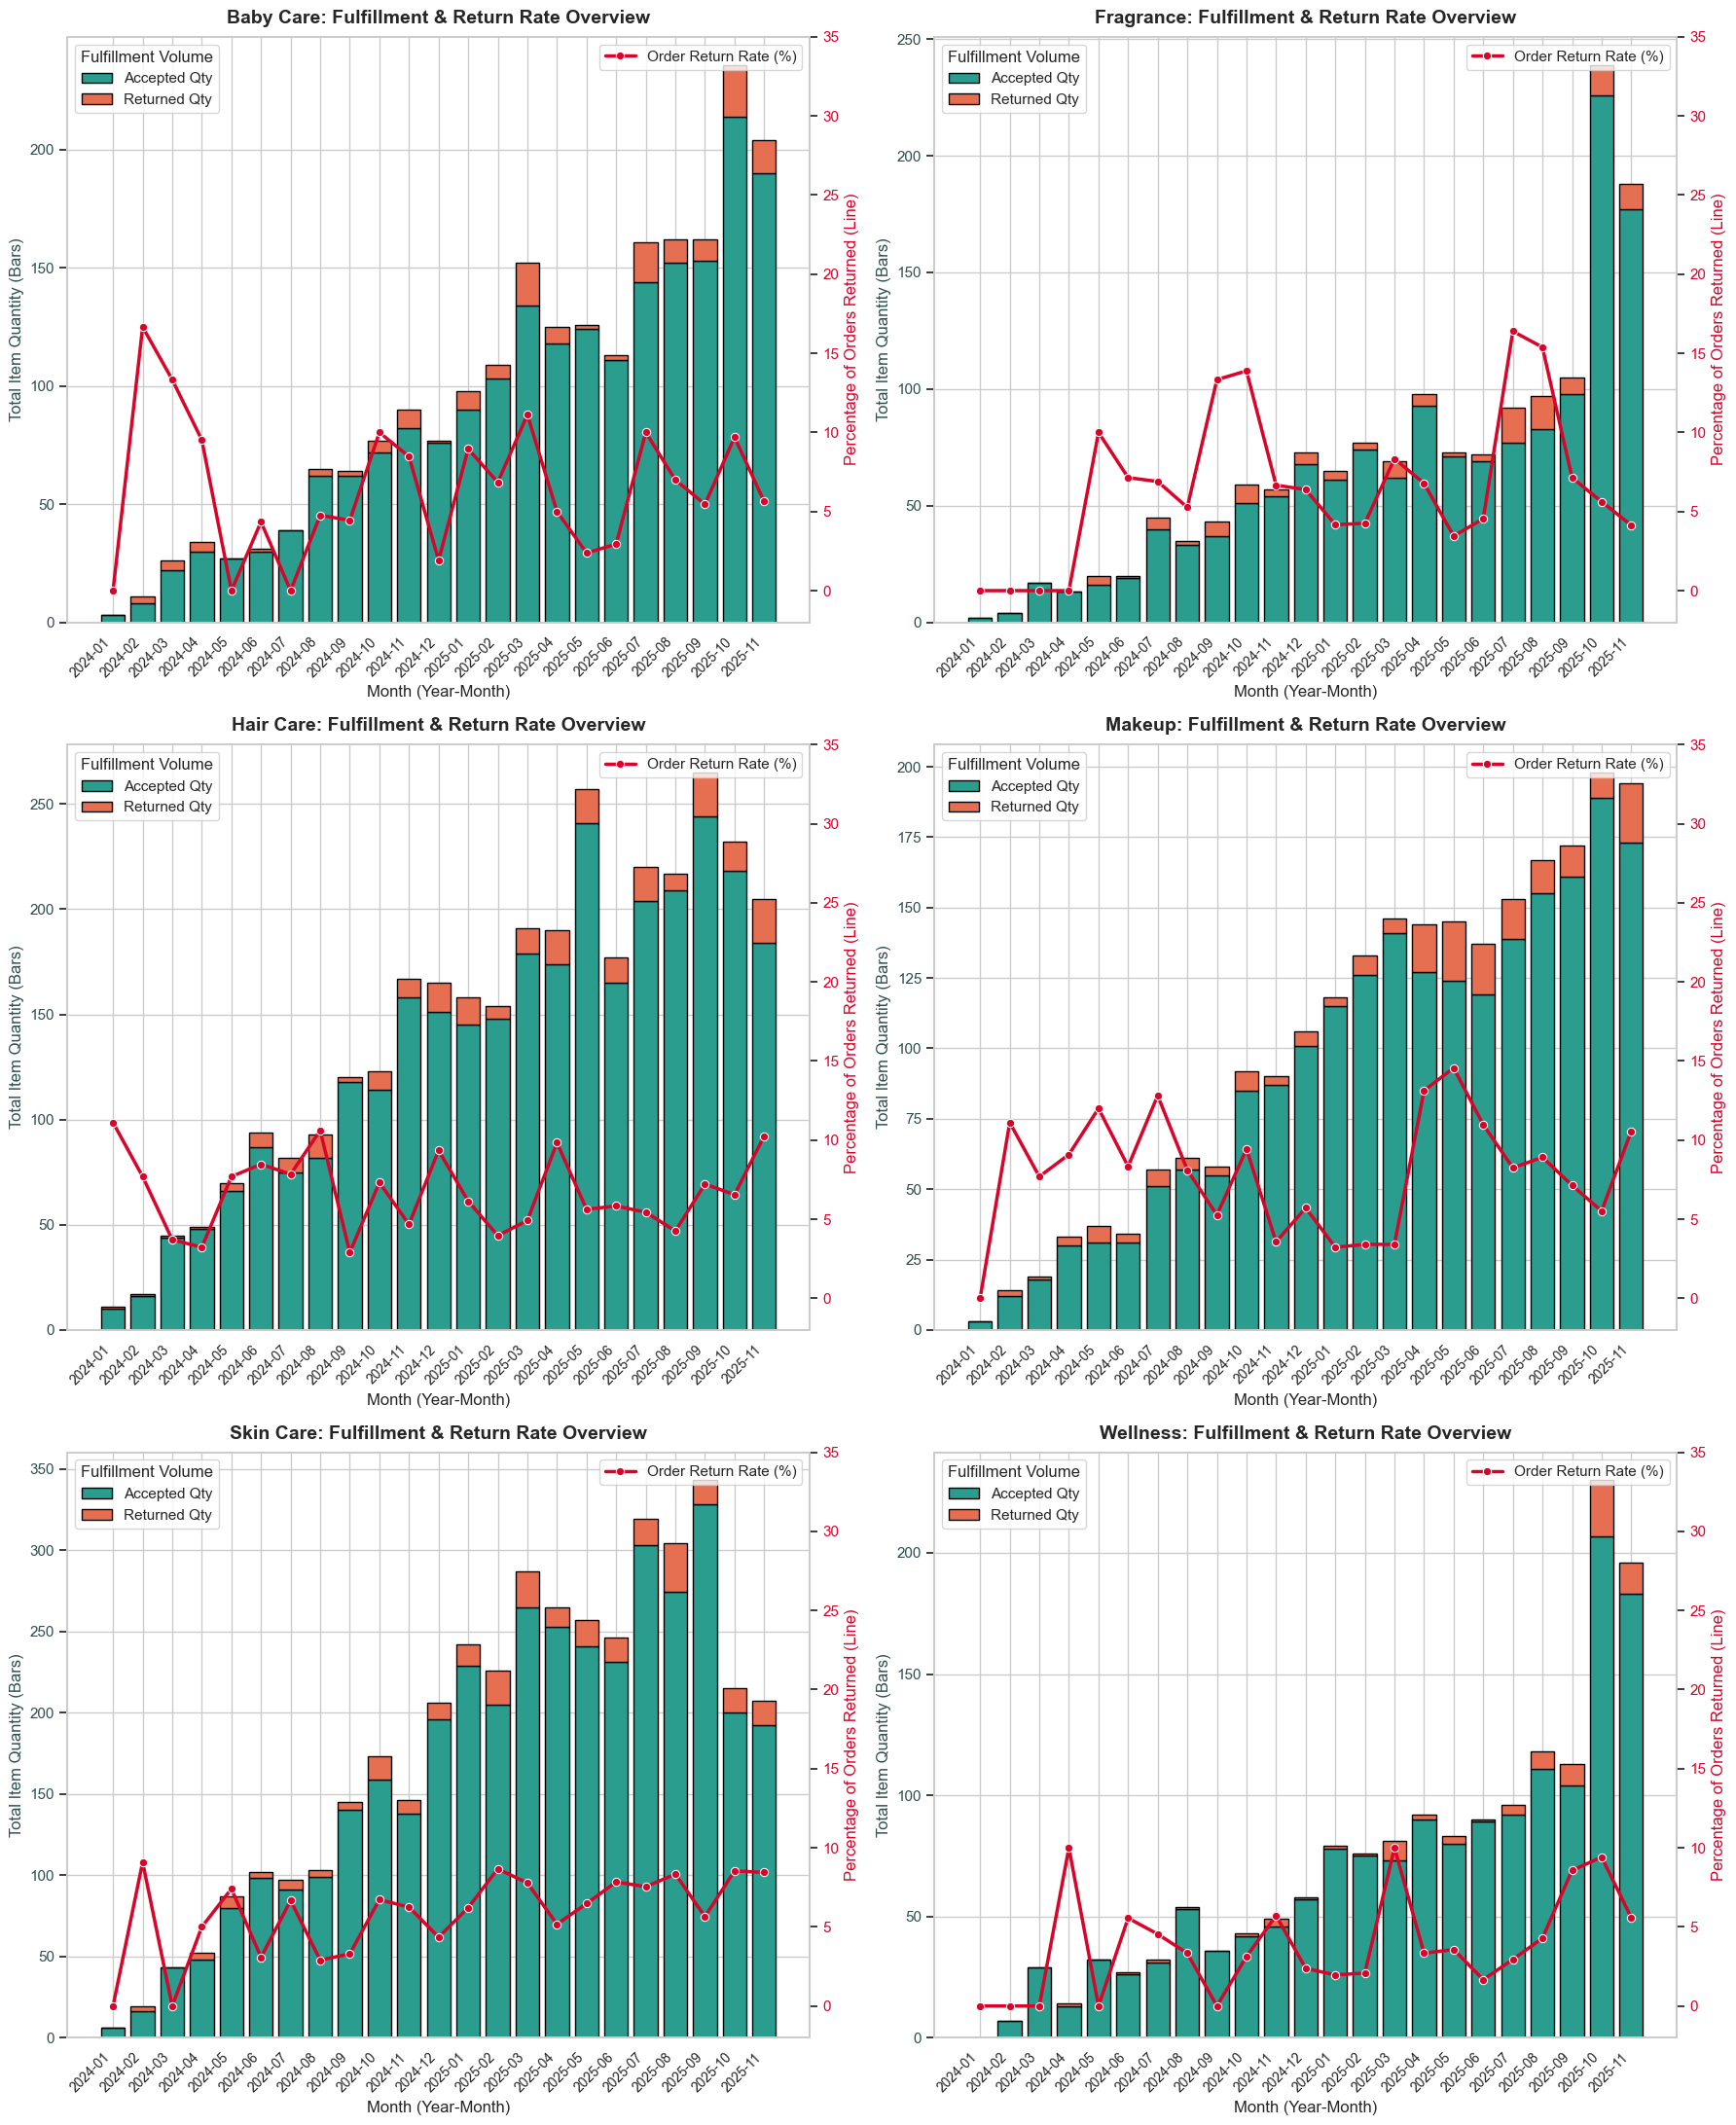

In [37]:
# 3e. Return/Refund behaviour


# 1. Extract Year-Month string periods for time progression
orders['year_month'] = orders['order_date'].dt.to_period('M').astype(str)

# 2. Derive separate granular items for structural quantities
orders['qty_returned'] = orders['quantity'] * orders['returned']
orders['qty_accepted'] = orders['quantity'] * (1 - orders['returned'])

# 3. Aggregate metrics by Category and Year-Month
agg_df = orders.groupby(['category', 'year_month']).agg(
    accepted_qty=('qty_accepted', 'sum'),
    returned_qty=('qty_returned', 'sum'),
    total_orders=('order_id', 'count'),
    returned_orders=('returned', 'sum')
).reset_index()

# 4. Calculate the true Order Return Rate Percentage 
agg_df['return_rate_pct'] = (agg_df['returned_orders'] / agg_df['total_orders']) * 100

# Extract sorting indices for plot alignment
categories = agg_df['category'].unique()
all_months = sorted(agg_df['year_month'].unique())

# 5. Set visualization aesthetic base
sns.set_theme(style="whitegrid")

# Create a 3x2 grid of subplots for the 6 categories
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 22))
axes = axes.flatten()

# 6. Populate each subplot with the dual-axis combo chart
for i, cat in enumerate(categories):
    ax1 = axes[i]
    
    # Reindex target category subset cleanly across all sequential months
    cat_data = agg_df[agg_df['category'] == cat].set_index('year_month').reindex(all_months).fillna(0).reset_index()
    
    # --- Primary Left Y-Axis: Stacked Bars (Quantities) ---
    ax1.bar(cat_data['year_month'], cat_data['accepted_qty'], label='Accepted Qty', color='#2a9d8f', edgecolor='black')
    ax1.bar(cat_data['year_month'], cat_data['returned_qty'], bottom=cat_data['accepted_qty'], label='Returned Qty', color='#e76f51', edgecolor='black')
    
    # Standard left axis labels and styling
    ax1.set_title(f'{cat}: Fulfillment & Return Rate Overview', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xlabel('Month (Year-Month)', fontsize=12)
    ax1.set_ylabel('Total Item Quantity (Bars)', fontsize=12, color='darkslategrey')
    ax1.set_xticks(range(len(all_months)))
    ax1.set_xticklabels(all_months, rotation=45, ha='right', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='darkslategrey')
    ax1.legend(title='Fulfillment Volume', loc='upper left', frameon=True)
    
    # --- Secondary Right Y-Axis: Line Graph (Order Return Rate %) ---
    ax2 = ax1.twinx()
    sns.lineplot(
        x=ax1.get_xticks(), 
        y=cat_data['return_rate_pct'], 
        ax=ax2, 
        color='#d90429', 
        linewidth=2.5, 
        marker='o', 
        markersize=6,
        label='Order Return Rate (%)'
    )
    
    # Standard right axis styling
    ax2.set_ylabel('Percentage of Orders Returned (Line)', fontsize=12, color='#d90429')
    ax2.tick_params(axis='y', labelcolor='#d90429')
    ax2.set_ylim(-2, 35)  # Constrain axis to clean 0-35% scaling frame
    ax2.grid(False)       # Turn off secondary grid lines to avoid visual noise
    ax2.legend(loc='upper right', frameon=True)

# 7. Apply layout padding and save output
plt.tight_layout()
image_name = image_path + 'T3P1_quantity_stacked_with_return_rate_line.png'
plt.savefig(image_name, dpi=300)

In [38]:
# f. web/app activity

# Basic Overview
print("=== Shape & Info ===")
print(f"Shape: {web.shape}")
print(web.info())

print("\n=== Missing Values ===")
print(web.isnull().sum())

print("\n=== Statistical Summary ===")
# Target numerical columns for analysis
numeric_cols = [
    'sessions_30d', 'product_views_30d', 'cart_adds_30d', 
    'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 
    'campaign_clicks_30d', 'last_visit_days_ago'
]
print(web[numeric_cols].describe())

print("\n=== Snapshot Date Check ===")
print(web['snapshot_date'].value_counts())

# Let's perform funnel analysis and check correlation
print("=== Conversion Funnel Estimates ===")
total_views = web['product_views_30d'].sum()
total_adds = web['cart_adds_30d'].sum()
total_abandoned = web['abandoned_carts_30d'].sum()

print(f"Total Product Views: {total_views}")
print(f"Total Cart Adds: {total_adds} ({total_adds/total_views*100:.2f}% of views)")
print(f"Total Abandoned Carts: {total_abandoned} ({total_abandoned/total_adds*100:.2f}% of cart adds)")

print("\n=== Inactive Users Check ===")
zero_sessions = web[web['sessions_30d'] == 0]
print(f"Users with 0 sessions in past 30 days: {len(zero_sessions)} ({len(zero_sessions)/len(web)*100:.2f}%)")

# Correlation Matrix
print("\n=== Correlation Matrix ===")
print(web[numeric_cols].corr())

=== Shape & Info ===
Shape: (2400, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   snapshot_date        2400 non-null   str  
 2   sessions_30d         2400 non-null   int64
 3   product_views_30d    2400 non-null   int64
 4   cart_adds_30d        2400 non-null   int64
 5   wishlist_adds_30d    2400 non-null   int64
 6   abandoned_carts_30d  2400 non-null   int64
 7   email_opens_30d      2400 non-null   int64
 8   campaign_clicks_30d  2400 non-null   int64
 9   last_visit_days_ago  2400 non-null   int64
dtypes: int64(8), str(2)
memory usage: 187.6 KB
None

=== Missing Values ===
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_cli

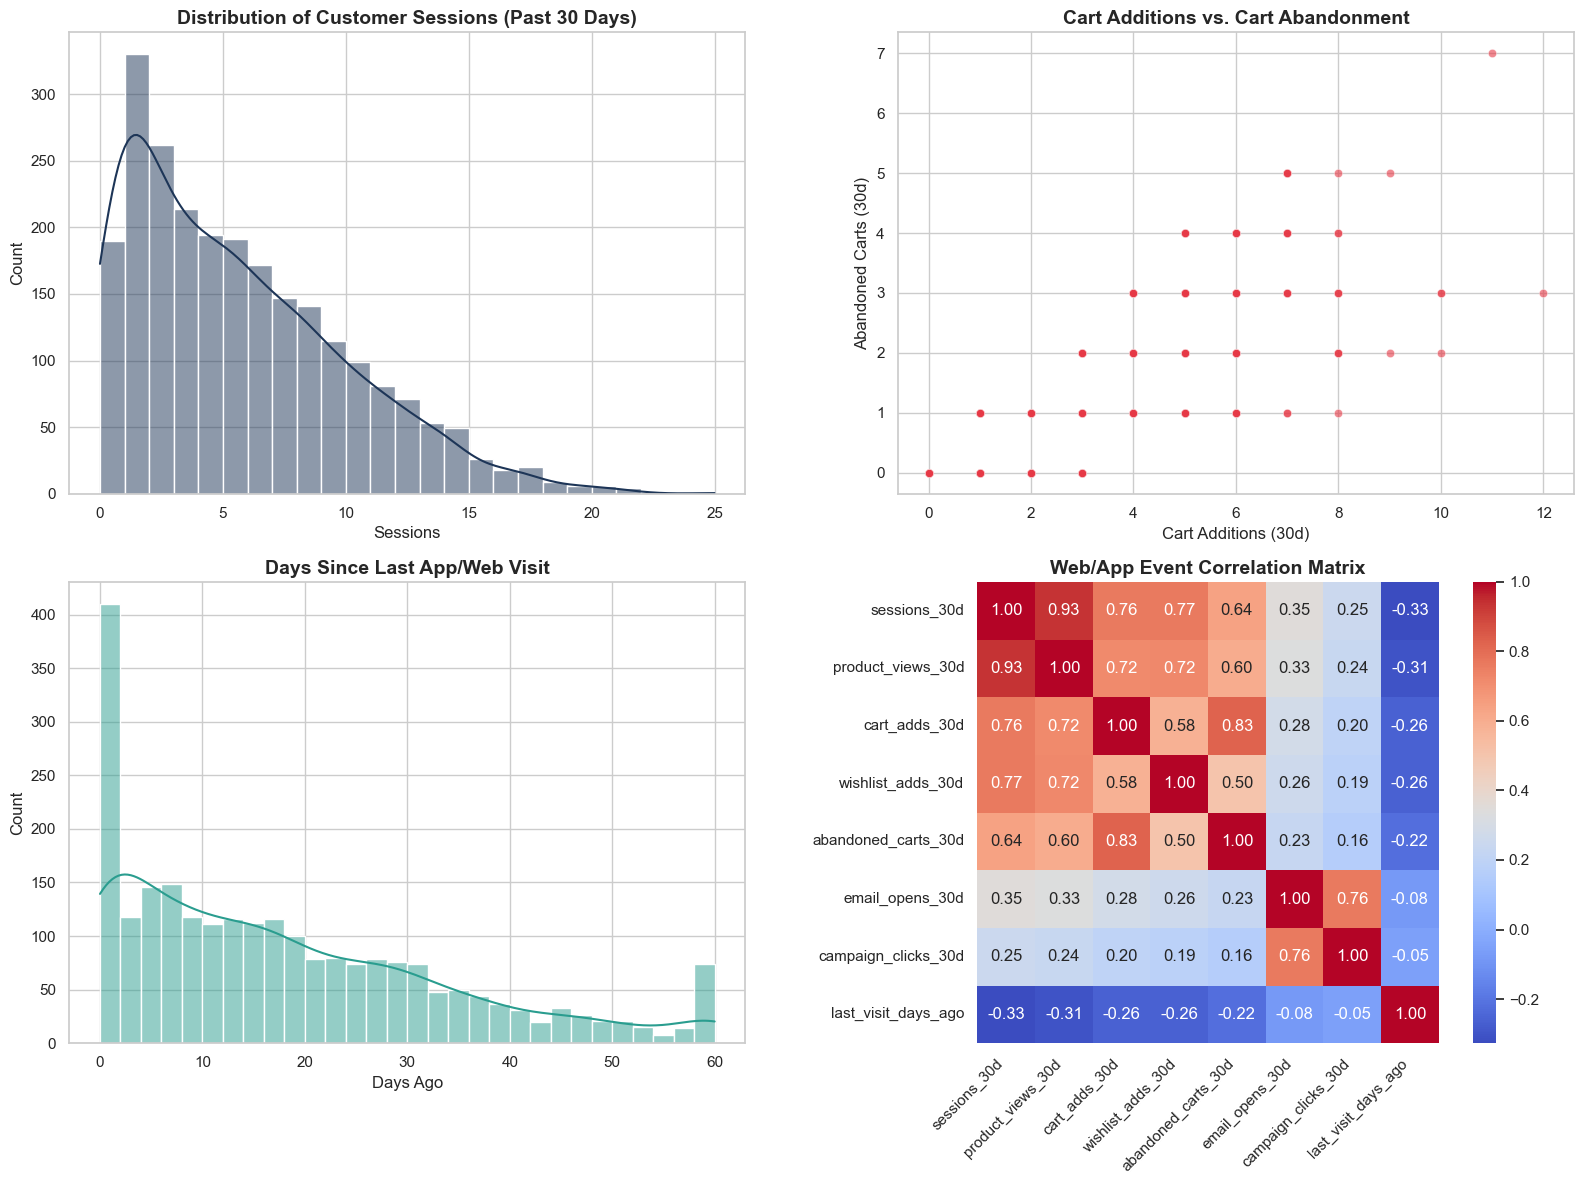

In [39]:
# f.

# Create diagnostic visualizations for Web/App Events Snapshot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of Sessions
sns.histplot(web['sessions_30d'], kde=True, ax=axes[0,0], color='#1d3557', bins=25)
axes[0,0].set_title('Distribution of Customer Sessions (Past 30 Days)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Sessions')
axes[0,0].set_ylabel('Count')

# 2. Relationship between Cart Adds and Abandoned Carts
sns.scatterplot(x='cart_adds_30d', y='abandoned_carts_30d', data=web, ax=axes[0,1], color='#e63946', alpha=0.6)
axes[0,1].set_title('Cart Additions vs. Cart Abandonment', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Cart Additions (30d)')
axes[0,1].set_ylabel('Abandoned Carts (30d)')

# 3. Recency of Last Visit
sns.histplot(web['last_visit_days_ago'], kde=True, ax=axes[1,0], color='#2a9d8f', bins=30)
axes[1,0].set_title('Days Since Last App/Web Visit', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Days Ago')
axes[1,0].set_ylabel('Count')

# 4. Correlation Heatmap
sns.heatmap(web[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1,1], cbar=True, square=True)
axes[1,1].set_title('Web/App Event Correlation Matrix', fontsize=14, fontweight='bold')
plt.setp(axes[1,1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
image_name = image_path + 'T3P1_web_events_eda_dashboard.png'
plt.savefig(image_name, dpi=300)


C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\homeadm\.conda\envs\myenv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


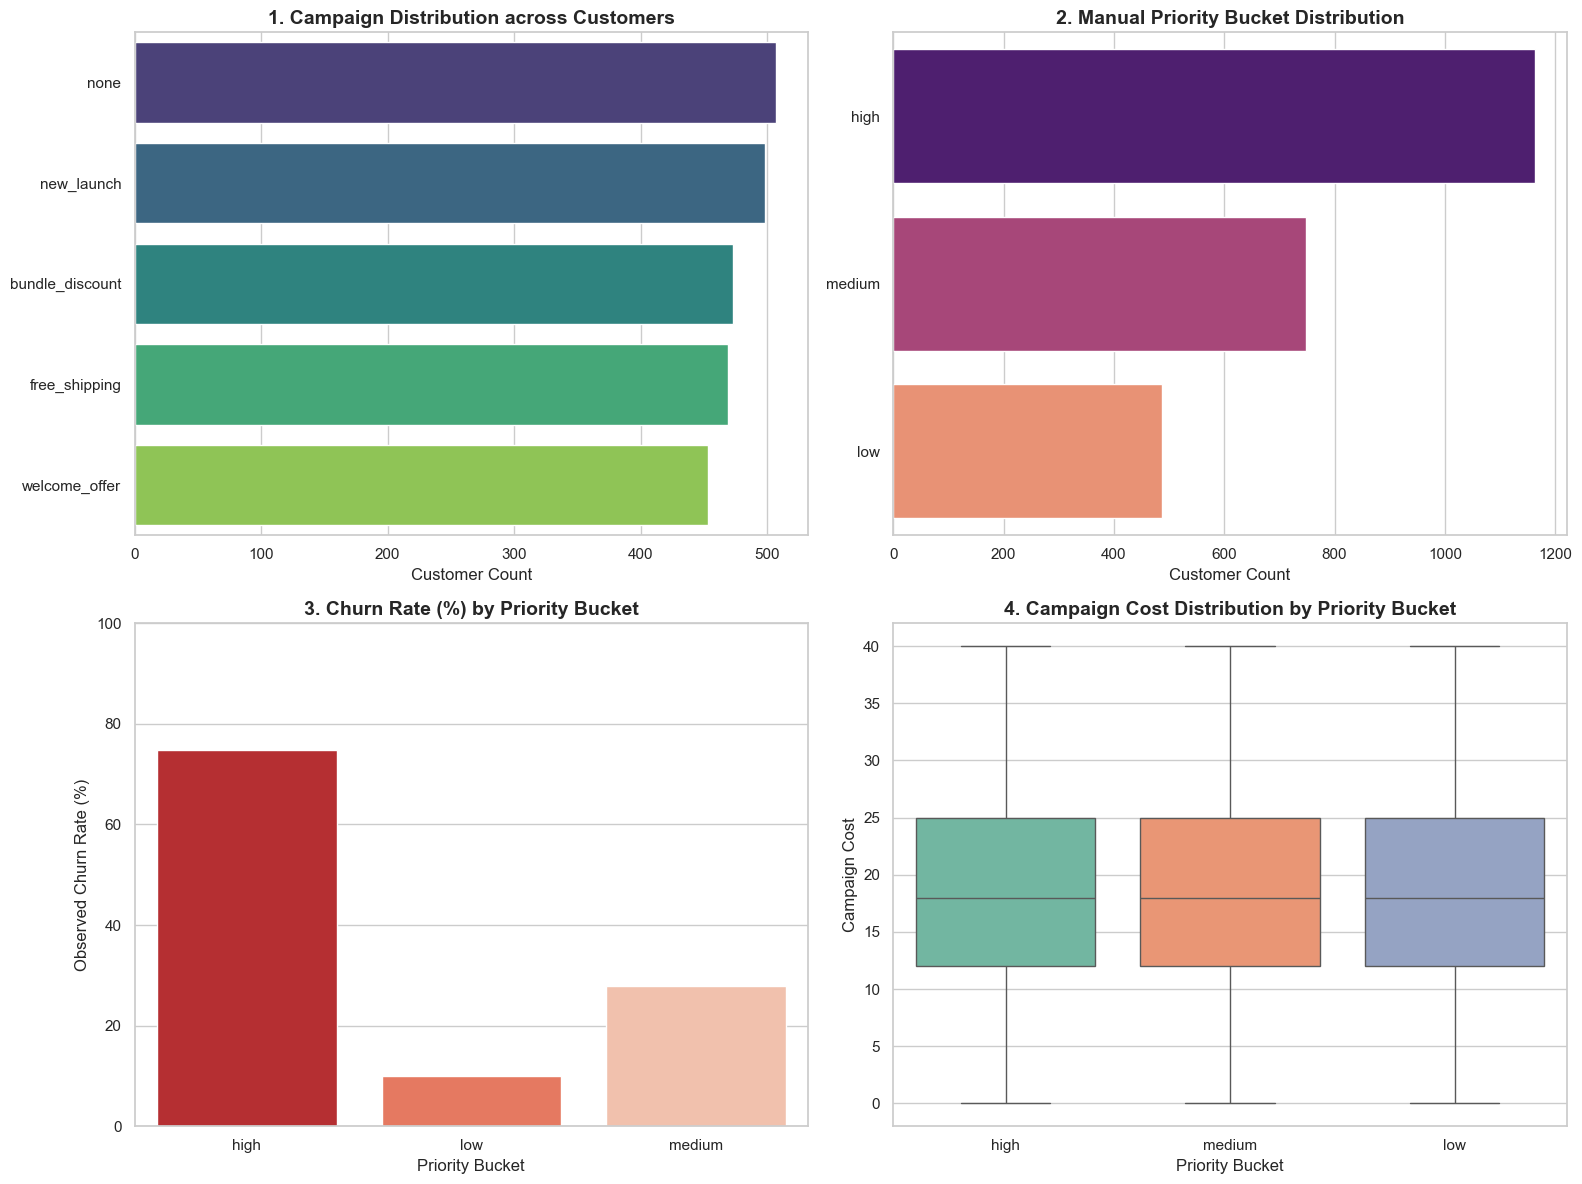

In [40]:
# g & h : Intervention history & churn distribution

# 1. Load intervention history and churn labels to analyze cross-impacts
merged = pd.merge(interv, churn, on='customer_id')

# 2. Setup seaborn template and subplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# Panel 1: Campaign Distribution across Customers
campaign_counts = merged['last_campaign_received'].value_counts().reset_index()
sns.barplot(x='count', y='last_campaign_received', data=campaign_counts, ax=axes[0,0], palette='viridis', hue='last_campaign_received')
axes[0,0].set_title('1. Campaign Distribution across Customers', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Customer Count')
axes[0,0].set_ylabel('')
if axes[0,0].get_legend() is not None: axes[0,0].get_legend().remove()

# Panel 2: Distribution of Manual Priority Buckets
priority_counts = merged['manual_priority_bucket'].value_counts().reset_index()
sns.barplot(x='count', y='manual_priority_bucket', data=priority_counts, ax=axes[0,1], palette='magma', hue='manual_priority_bucket')
axes[0,1].set_title('2. Manual Priority Bucket Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Customer Count')
axes[0,1].set_ylabel('')
if axes[0,1].get_legend() is not None: axes[0,1].get_legend().remove()

# Panel 3: Churn Rate (%) by Priority Bucket (Crucial Operational Link)
priority_churn = merged.groupby('manual_priority_bucket')['churn_next_60d'].mean().reset_index()
priority_churn['churn_rate_pct'] = priority_churn['churn_next_60d'] * 100
sns.barplot(x='manual_priority_bucket', y='churn_rate_pct', data=priority_churn, ax=axes[1,0], palette='Reds_r', hue='manual_priority_bucket')
axes[1,0].set_title('3. Churn Rate (%) by Priority Bucket', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Priority Bucket')
axes[1,0].set_ylabel('Observed Churn Rate (%)')
axes[1,0].set_ylim(0, 100)
if axes[1,0].get_legend() is not None: axes[1,0].get_legend().remove()

# Panel 4: Boxplot of Campaign Cost by Priority Bucket
sns.boxplot(x='manual_priority_bucket', y='last_campaign_cost', data=merged, ax=axes[1,1], palette='Set2', hue='manual_priority_bucket')
axes[1,1].set_title('4. Campaign Cost Distribution by Priority Bucket', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Priority Bucket')
axes[1,1].set_ylabel('Campaign Cost')
if axes[1,1].get_legend() is not None: axes[1,1].get_legend().remove()

# Refine and layout spacing parameters
plt.tight_layout()
image_name = image_path + 'T3P1_intervention_history_eda_dashboard.png'
plt.savefig(image_name, dpi=300)


C:\Users\homeadm\AppData\Local\Temp\ipykernel_19044\353522460.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])


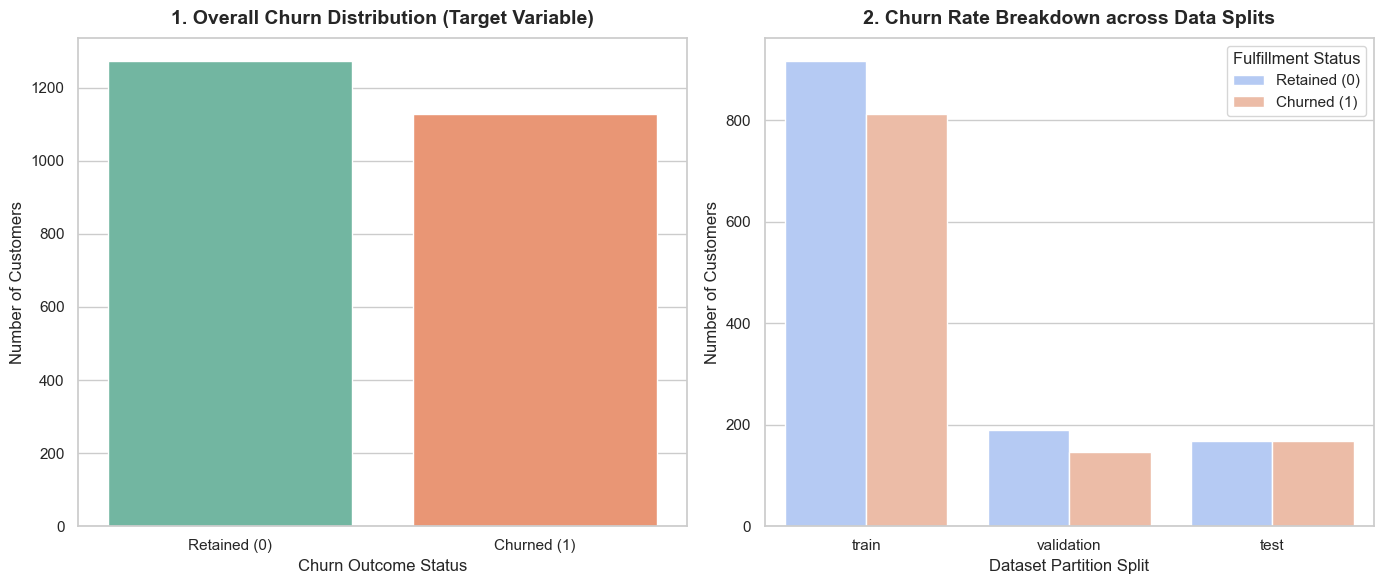

In [41]:
# h. Churn distribution

# 2. Extract structural and breakdown metrics
overall_counts = churn['churn_next_60d'].value_counts()
overall_pct = churn['churn_next_60d'].value_counts(normalize=True) * 100

cross_tab = pd.to_datetime(churn['snapshot_date']).value_counts()
cross_split_counts = pd.crosstab(churn['split'], churn['churn_next_60d'])
cross_split_pct = pd.crosstab(churn['split'], churn['churn_next_60d'], normalize='index') * 100

# 3. Setup Seaborn theme and canvas template
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Panel 1: Overall Target Variable Class Balance
sns.countplot(x='churn_next_60d', data=churn, ax=axes[0], palette='Set2', hue='churn_next_60d')
axes[0].set_title('1. Overall Churn Distribution (Target Variable)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Churn Outcome Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

# Panel 2: Class Balance Multi-grouping Across Analytical Splits
sns.countplot(x='split', hue='churn_next_60d', data=churn, ax=axes[1], palette='coolwarm')
axes[1].set_title('2. Churn Rate Breakdown across Data Splits', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Dataset Partition Split')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Fulfillment Status', labels=['Retained (0)', 'Churned (1)'], frameon=True)

# 4. Enforce clean margins and save plot to disk
plt.tight_layout()
image_name = image_path + 'T3P1_churn_labels_eda_dashboard.png'
plt.savefig(image_name, dpi=300)


## 4.	Identify at least five churn-risk hypotheses from your analysis. Each hypothesis must be supported by a chart/table and a short explanation.

Generating Plot 1: Order Recency...
Generating Plot 2: App/Web Visit Recency...
Generating Plot 3: Purchase Frequency...
Generating Plot 4: Product Views...
Generating Plot 5: Manual Priority Buckets...
Generating Plot 6: Loyalty Tiers...
Generating Plot 7: Cart Abandonment...


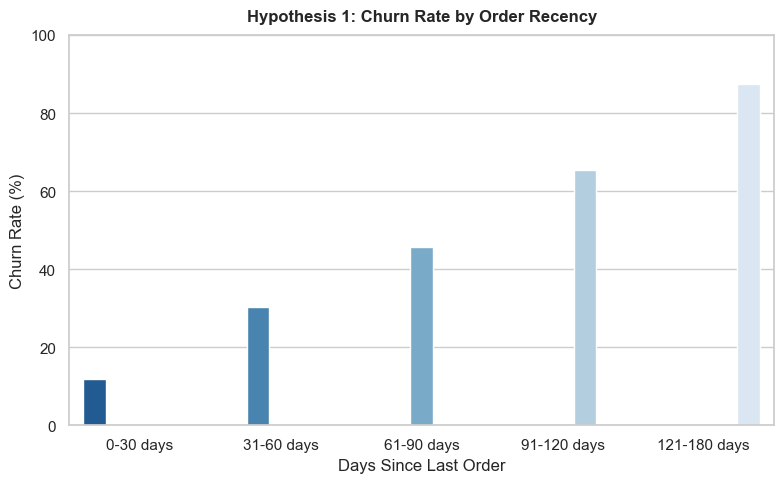

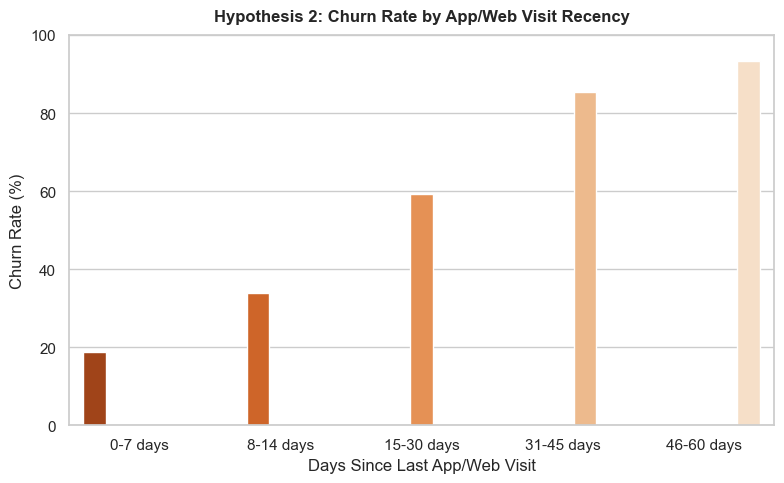

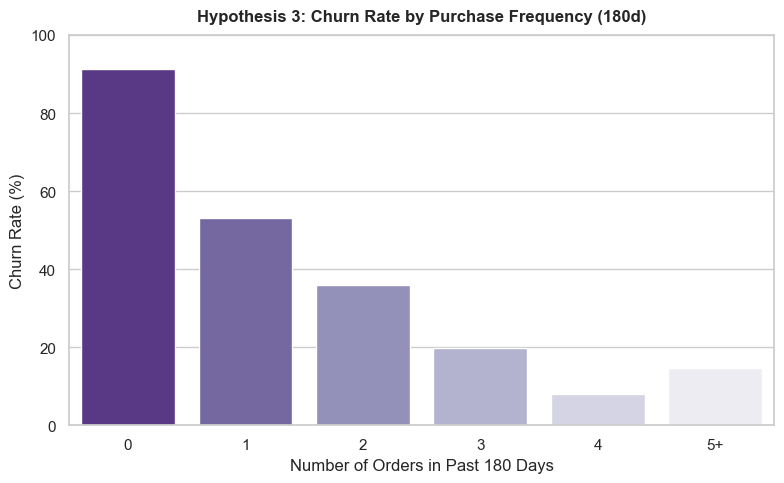

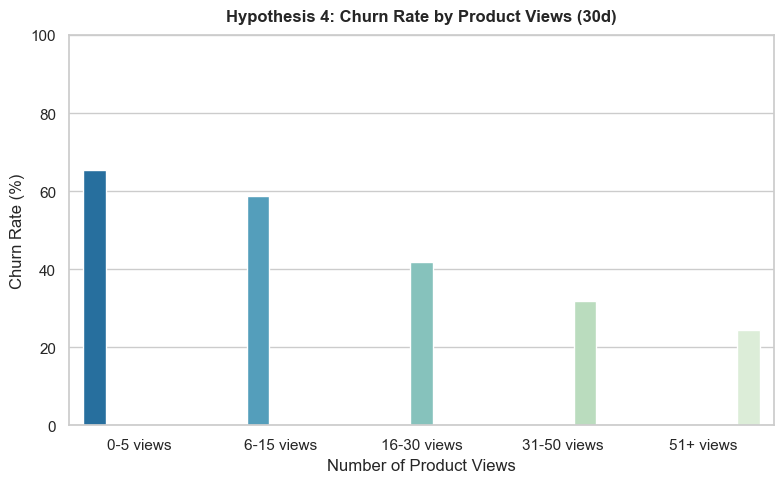

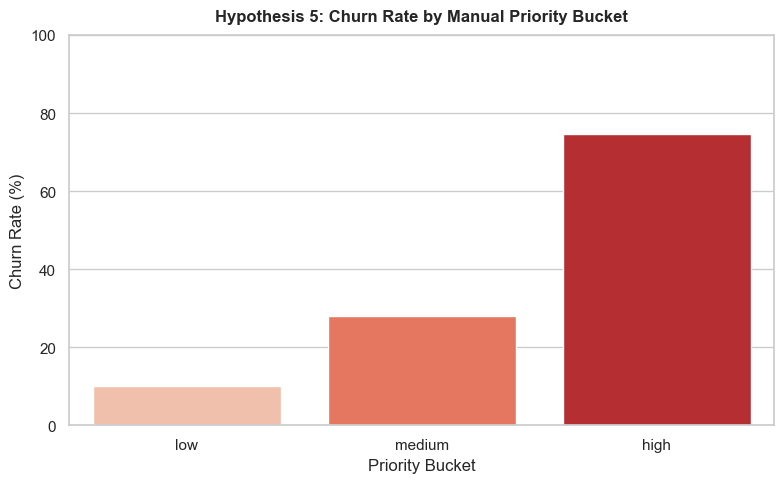

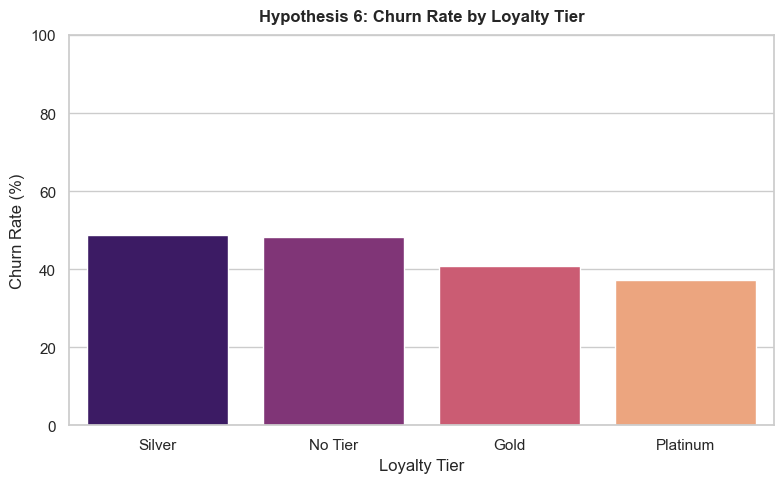

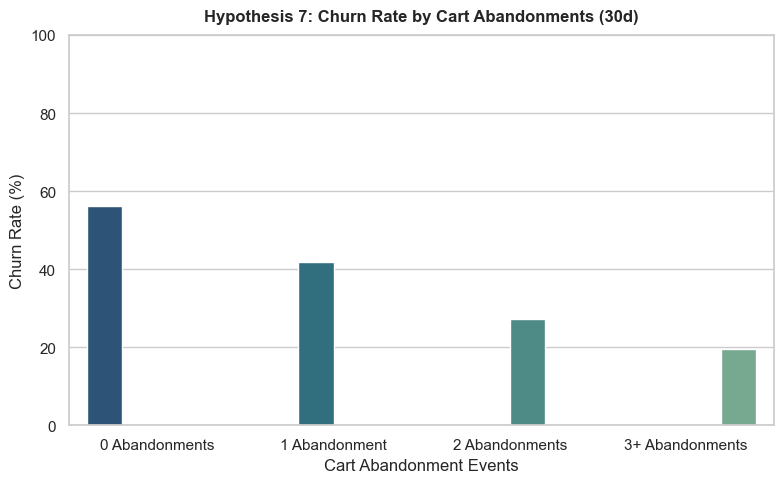

In [42]:
sns.set_theme(style="whitegrid")

# =========================================================================
# HYPOTHESIS 1: Transactional Recency Fatigue
# =========================================================================
print("Generating Plot 1: Order Recency...")
rfm['order_recency_bins'] = pd.cut(
    rfm['recency_days'], 
    bins=[-1, 30, 60, 90, 120, 180], 
    labels=['0-30 days', '31-60 days', '61-90 days', '91-120 days', '121-180 days']
)
h1 = rfm.groupby('order_recency_bins', observed=False)['churn_next_60d'].agg(
    churn_rate='mean').reset_index()
h1['churn_rate_pct'] = h1['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='order_recency_bins', y='churn_rate_pct', data=h1, palette='Blues_r', hue='order_recency_bins', ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_title('Hypothesis 1: Churn Rate by Order Recency', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Days Since Last Order')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()

image_name = image_path + 'T3P1_hypothesis_1_order_recency.png'
plt.savefig(image_name, dpi=300)
# plt.savefig('hypothesis_1_order_recency.png', dpi=300)
# plt.close()

# =========================================================================
# HYPOTHESIS 2: Digital Session Recency Detachment
# =========================================================================
print("Generating Plot 2: App/Web Visit Recency...")
rfm['last_visit_bins'] = pd.cut(
    rfm['last_visit_days_ago'], 
    bins=[-1, 7, 14, 30, 45, 60], 
    labels=['0-7 days', '8-14 days', '15-30 days', '31-45 days', '46-60 days']
)
h2 = rfm.groupby('last_visit_bins', observed=False)['churn_next_60d'].agg(
    churn_rate='mean'
).reset_index()
h2['churn_rate_pct'] = h2['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='last_visit_bins', y='churn_rate_pct', data=h2, palette='Oranges_r', hue='last_visit_bins', ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_title('Hypothesis 2: Churn Rate by App/Web Visit Recency', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Days Since Last App/Web Visit')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
image_name = image_path + 'T3P1_hypothesis_2_visit_recency.png'
plt.savefig(image_name, dpi=300)
# plt.savefig('hypothesis_2_visit_recency.png', dpi=300)
# plt.close()

# =========================================================================
# HYPOTHESIS 3: Transactional Frequency Lock-In
# =========================================================================
print("Generating Plot 3: Purchase Frequency...")
rfm['freq_clean'] = rfm['frequency_180d'].apply(lambda x: str(x) if x < 5 else '5+')
h3 = rfm.groupby('freq_clean', observed=False)['churn_next_60d'].agg(
    churn_rate='mean'
).reset_index()
h3['churn_rate_pct'] = h3['churn_rate'] * 100
h3 = h3.sort_values('freq_clean')

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='freq_clean', y='churn_rate_pct', data=h3, palette='Purples_r', hue='freq_clean', ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_title('Hypothesis 3: Churn Rate by Purchase Frequency (180d)', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Number of Orders in Past 180 Days')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
image_name = image_path + 'T3P1_hypothesis_3_purchase_frequency.png'
plt.savefig(image_name, dpi=300)
# plt.savefig('hypothesis_3_purchase_frequency.png', dpi=300)
# plt.close()

# =========================================================================
# HYPOTHESIS 4: Digital Catalog Browsing Intensity
# =========================================================================
print("Generating Plot 4: Product Views...")
rfm['views_bins'] = pd.cut(
    rfm['product_views_30d'], 
    bins=[-1, 5, 15, 30, 50, 200], 
    labels=['0-5 views', '6-15 views', '16-30 views', '31-50 views', '51+ views']
)
h4 = rfm.groupby('views_bins', observed=False)['churn_next_60d'].agg(
    churn_rate='mean'
).reset_index()
h4['churn_rate_pct'] = h4['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='views_bins', y='churn_rate_pct', data=h4, palette='GnBu_r', hue='views_bins', ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_title('Hypothesis 4: Churn Rate by Product Views (30d)', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Number of Product Views')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
image_name = image_path + 'T3P1_hypothesis_4_product_views.png'
plt.savefig(image_name, dpi=300)
# plt.savefig('hypothesis_4_product_views.png', dpi=300)
# plt.close()

# =========================================================================
# HYPOTHESIS 5: Human Heuristic Validation (Priority Buckets)
# =========================================================================
print("Generating Plot 5: Manual Priority Buckets...")
h5 = interv.merge(rfm[['customer_id', 'churn_next_60d']], on='customer_id')
h5_agg = h5.groupby('manual_priority_bucket')['churn_next_60d'].agg(
    churn_rate='mean'
).reset_index()
h5_agg['churn_rate_pct'] = h5_agg['churn_rate'] * 100
h5_agg = h5_agg.sort_values('churn_rate_pct')

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='manual_priority_bucket', y='churn_rate_pct', data=h5_agg, palette='Reds', hue='manual_priority_bucket', ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_title('Hypothesis 5: Churn Rate by Manual Priority Bucket', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Priority Bucket')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
image_name = image_path + 'T3P1_hypothesis_5_priority_bucket.png'
plt.savefig(image_name, dpi=300)
# plt.savefig('hypothesis_5_priority_bucket.png', dpi=300)
# plt.close()

# =========================================================================
# HYPOTHESIS 6: Premium Loyalty Tier Cushion
# =========================================================================
print("Generating Plot 6: Loyalty Tiers...")
rfm['loyalty_tier_clean'] = rfm['loyalty_tier'].fillna('No Tier')
h6 = rfm.groupby('loyalty_tier_clean')['churn_next_60d'].agg(
    churn_rate='mean'
).reset_index()
h6['churn_rate_pct'] = h6['churn_rate'] * 100
h6 = h6.sort_values('churn_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='loyalty_tier_clean', y='churn_rate_pct', data=h6, palette='magma', hue='loyalty_tier_clean', ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_title('Hypothesis 6: Churn Rate by Loyalty Tier', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Loyalty Tier')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
image_name = image_path + 'T3P1_hypothesis_6_loyalty_tier.png'
plt.savefig(image_name, dpi=300)
# plt.savefig('hypothesis_6_loyalty_tier.png', dpi=300)
# plt.close()

# =========================================================================
# HYPOTHESIS 7: The Cart Abandonment Engagement Paradox
# =========================================================================
print("Generating Plot 7: Cart Abandonment...")
rfm['abandoned_bins'] = pd.cut(
    rfm['abandoned_carts_30d'], 
    bins=[-1, 0, 1, 2, 10], 
    labels=['0 Abandonments', '1 Abandonment', '2 Abandonments', '3+ Abandonments']
)
h7 = rfm.groupby('abandoned_bins', observed=False)['churn_next_60d'].agg(
    churn_rate='mean'
).reset_index()
h7['churn_rate_pct'] = h7['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='abandoned_bins', y='churn_rate_pct', data=h7, palette='crest_r', hue='abandoned_bins', ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_title('Hypothesis 7: Churn Rate by Cart Abandonments (30d)', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Cart Abandonment Events')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
image_name = image_path + 'T3P1_hypothesis_7_cart_abandonment.png'
plt.savefig(image_name, dpi=300)
plt.savefig('hypothesis_7_cart_abandonment.png', dpi=300)
# plt.close()

In [43]:
# Save cleaned up orders list

clean_orders = dfs['Orders']

# Remove orders with order id ending in _DUP
clean_orders = clean_orders[~clean_orders['order_id'].str.endswith('_DUP', na=False)]

# Remove orders with orders after snapshot date (30 Sep 25)
snapshot_date = pd.to_datetime("2025-09-30")
clean_orders.order_date = pd.to_datetime(clean_orders.order_date)
clean_orders = clean_orders[clean_orders['order_date'] <= snapshot_date]

print (f"Before cleanup : {len(dfs['Orders'])} rows")
print (f"After cleanup : {len(clean_orders)} rows")

# save as csv file
file_name = data_path + "clean_orders.csv"
clean_orders.to_csv(file_name, index=False)
print ("Cleaned Order file saved - clean_orders.csv")

Before cleanup : 10009 rows
After cleanup : 8128 rows
Cleaned Order file saved - clean_orders.csv
